# The Beggining - Stock Price Precition

## Refresh the data and save into a DB

In [17]:
import yfinance as yf
import pandas as pd
import sqlite3
import hashlib
import re
from datetime import datetime
import matplotlib.pyplot as plt
import requests
import json
import xml.etree.ElementTree as ET

# 1. Configuration
DB_NAME = '/home/erfontes/research/trader/market_data.db'
tickers = ["GOOGL", "COST", "NVDA", "TSLA", "^VIX", "AMD", "SPY", "QQQ"]
MAX_ARTICLES_PER_TICKER_PER_DAY = 8

# ==============================================================================
# Domain / Publisher Blacklist & Tier System
# ==============================================================================
BLACKLIST_PUBLISHERS = {
    "mlb.com", "milb.com", "espn", "sports", "entertainment", "hollywood", "tmz",
    "polygon", "ign.com", "kotaku", "bleacher report", "cbs sports", "si.com",
    "athletics", "technosports"
}

PUBLISHER_TIERS = {
    "tier_1": [
        "bloomberg", "reuters", "wall street journal", "wsj", "financial times",
        "pr newswire", "business wire", "sec", "globe newswire", "cnbc", "dow jones"
    ],
    "tier_2": [
        "barron's", "barrons", "marketwatch", "investor's business daily", "ibd",
        "seeking alpha", "yahoo finance", "investing.com", "barchart", "thefly",
        "insider monkey", "tipranks", "forbes", "fortune", "techcrunch", "thestreet"
    ],
    "tier_3": [
        "marketbeat", "motley fool", "the motley fool", "24/7 wall st.",
        "stocktwits", "benzinga", "zacks", "simply wall st.", "gurufocus", "moomoo"
    ]
}

TICKER_KEYWORDS = {
    'NVDA': ['nvidia', 'nvda', 'jensen huang', 'geforce', 'blackwell', 'cuda', 'h100', 'b200'],
    'TSLA': ['tesla', 'tsla', 'elon musk', 'cybertruck', 'robotaxi', 'supercharger', 'gigafactory'],
    'GOOGL': ['google', 'googl', 'alphabet', 'sundar pichai', 'gemini', 'waymo', 'deepmind', 'youtube', 'pixel'],
    'AMD': ['amd', 'lisa su', 'radeon', 'epyc', 'ryzen', 'instinct', 'mi300', 'semi-custom'],
    'COST': ['costco', 'cost', 'membership', 'warehouse', 'wholesale', 'retail sales'],
    'SPY': ['s&p 500', 's&p500', 'spy', 'stock market', 'wall street', 'federal reserve', 'fed rate', 'cpi', 'inflation', 'treasury'],
    'QQQ': ['nasdaq', 'qqq', 'tech sector', 'tech stocks', 'big tech', 'magnificent 7', 'invesco'],
    '^VIX': ['vix', 'volatility', 'cboe', 'fear index', 'market volatility', 'option skew']
}

def get_publisher_tier_and_weight(publisher_name: str) -> tuple:
    """Returns (tier_int, weight_float) based on publisher authority."""
    if not publisher_name:
        return 3, 0.25
    name_clean = str(publisher_name).lower().strip()
    for bl in BLACKLIST_PUBLISHERS:
        if bl in name_clean:
            return 0, 0.0  # Blacklisted
    for t1 in PUBLISHER_TIERS["tier_1"]:
        if t1 in name_clean:
            return 1, 1.00
    for t2 in PUBLISHER_TIERS["tier_2"]:
        if t2 in name_clean:
            return 2, 0.60
    for t3 in PUBLISHER_TIERS["tier_3"]:
        if t3 in name_clean:
            return 3, 0.25
    return 2, 0.50

def compute_relevance_score(ticker: str, title: str, summary: str) -> float:
    """Scores direct keyword relevance of the article to the company."""
    keywords = TICKER_KEYWORDS.get(ticker, [ticker.lower()])
    title_lower = str(title).lower()
    summary_lower = str(summary).lower()
    score = 0.0
    for kw in keywords:
        if kw in title_lower:
            score += 0.60
            break
    for kw in keywords:
        if kw in summary_lower:
            score += 0.30
            break
    return score

def clean_title_tokens(title: str) -> set:
    """Extract normalized alphanumeric word tokens for Jaccard similarity."""
    cleaned = re.sub(r'[^a-zA-Z0-9\s]', ' ', str(title).lower())
    words = [w for w in cleaned.split() if len(w) > 2 and w not in {'the', 'and', 'for', 'with', 'this', 'that', 'why', 'how'}]
    return set(words)

def compute_headline_similarity(tokens_a: set, tokens_b: set) -> float:
    """Calculates Jaccard overlap similarity between two headline token sets."""
    if not tokens_a or not tokens_b:
        return 0.0
    intersection = len(tokens_a.intersection(tokens_b))
    union = len(tokens_a.union(tokens_b))
    return intersection / union if union > 0 else 0.0

def get_db_connection():
    """Returns a connection to the SQLite database."""
    return sqlite3.connect(DB_NAME)

def init_db():
    """Initialize the SQLite database with the required tables, indexes, and migrations."""
    conn = get_db_connection()
    conn.execute("""
        CREATE TABLE IF NOT EXISTS prices (
            Date TEXT,
            Ticker TEXT,
            Price REAL,
            Volume REAL,
            Open REAL,
            High REAL,
            Low REAL,
            PRIMARY KEY (Date, Ticker)
        )
    """)
    for col, col_type in [("Volume", "REAL DEFAULT 0.0"), ("Open", "REAL"), ("High", "REAL"), ("Low", "REAL")]:
        try:
            conn.execute(f"ALTER TABLE prices ADD COLUMN {col} {col_type}")
        except Exception:
            pass
    conn.execute("""
        CREATE TABLE IF NOT EXISTS news (
            NewsID TEXT PRIMARY KEY,
            Ticker TEXT,
            Date TEXT,
            Title TEXT,
            Summary TEXT,
            Publisher TEXT,
            Link TEXT,
            Processed INTEGER DEFAULT 0
        )
    """)
    conn.execute("CREATE INDEX IF NOT EXISTS idx_prices_ticker_date ON prices (Ticker, Date)")
    conn.execute("CREATE INDEX IF NOT EXISTS idx_news_ticker_date ON news (Ticker, Date)")
    conn.execute("CREATE INDEX IF NOT EXISTS idx_news_processed ON news (Processed)")
    conn.commit()
    conn.close()

def update_prices():
    """Fetches the last 30 days of OHLCV data for all tickers and updates the prices table."""
    print("📈 Updating Prices from yfinance (last 30 days)...", end=" ")
    conn = get_db_connection()
    new_records = 0
    for ticker in tickers:
        try:
            df = yf.download(ticker, period="30d", interval="1d", progress=False)
            if not df.empty:
                if isinstance(df.columns, pd.MultiIndex):
                    df.columns = df.columns.get_level_values(0)
                
                df = df.reset_index()
                df = df.dropna(subset=['Date', 'Close'])
                df['Date'] = pd.to_datetime(df['Date']).dt.strftime('%Y-%m-%d')
                df['Ticker'] = ticker
                
                clean_df = pd.DataFrame({
                    'Date': df['Date'],
                    'Ticker': df['Ticker'],
                    'Price': df['Close'],
                    'Volume': df['Volume'] if 'Volume' in df.columns else 0.0,
                    'Open': df['Open'] if 'Open' in df.columns else df['Close'],
                    'High': df['High'] if 'High' in df.columns else df['Close'],
                    'Low': df['Low'] if 'Low' in df.columns else df['Close']
                })
                
                clean_df.to_sql("temp_prices", conn, if_exists="replace", index=False)
                cursor = conn.execute("""
                    INSERT OR REPLACE INTO prices (Date, Ticker, Price, Volume, Open, High, Low)
                    SELECT Date, Ticker, Price, Volume, Open, High, Low FROM temp_prices
                """)
                conn.execute("DROP TABLE temp_prices")
                new_records += cursor.rowcount
        except Exception as e:
            print(f"\nError updating prices for {ticker}: {e}")
    conn.commit()
    conn.close()
    print(f"Done! (Synchronized {new_records} records)")

def update_news():
    """
    High-Signal Curated Dual-Source News Ingestion:
    1. Blacklist & Relevance Filter: Rejects noise, sports, and off-topic articles.
    2. Headline Deduplication: Collapses syndicated duplicate stories within the same day.
    3. Daily Quota: Caps each ticker at the top 8 highest-authority articles per day.
    """
    print("📰 Processing Curated High-Signal News Feeds (Capped at 8/stock/day)...")
    conn = get_db_connection()
    new_items = 0
    filtered_noise = 0
    deduped_items = 0
    
    ticker_search = {
        'GOOGL': 'Alphabet+Google',
        'NVDA': 'NVIDIA',
        'TSLA': 'Tesla',
        'AMD': 'Advanced+Micro+Devices+AMD',
        'COST': 'Costco',
        '^VIX': 'VIX+Volatility',
        'SPY': 'S&P+500+Stock+Market',
        'QQQ': 'Nasdaq+100+Tech+Market',
    }
    
    for ticker in tickers:
        existing_headlines = conn.execute("SELECT Date, Title FROM news WHERE Ticker = ?", (ticker,)).fetchall()
        existing_token_map = {}
        daily_count_map = {}
        for edate, etitle in existing_headlines:
            eday = str(edate)[:10]
            existing_token_map.setdefault(eday, []).append(clean_title_tokens(etitle))
            daily_count_map[eday] = daily_count_map.get(eday, 0) + 1

        candidate_articles = []

        # A. Live Feed: Yahoo Finance
        try:
            stock = yf.Ticker(ticker)
            stories = stock.news or []
            for story in stories:
                content = story.get('content', {})
                provider = content.get('provider', {})
                title = content.get('title', 'No Title')
                summary = content.get('summary', 'No Summary')
                publisher = provider.get('displayName', 'Yahoo Finance')
                
                tier, weight = get_publisher_tier_and_weight(publisher)
                if tier == 0:
                    filtered_noise += 1
                    continue
                
                rel_score = compute_relevance_score(ticker, title, summary)
                if rel_score == 0:
                    filtered_noise += 1
                    continue
                
                raw_date = content.get('pubDate', datetime.now().isoformat())
                try:
                    clean_date = pd.to_datetime(raw_date).strftime('%Y-%m-%d %H:%M:%S')
                except:
                    clean_date = str(raw_date)
                    
                link = content.get('canonicalUrl', {}).get('url', '')
                candidate_articles.append({
                    'ticker': ticker, 'date': clean_date, 'title': title, 'summary': summary,
                    'publisher': publisher, 'link': link, 'score': weight * (1.0 + rel_score)
                })
        except Exception as e:
            print(f"Yahoo News notice for {ticker}: {e}")

        # B. Gap-Healing: Google News RSS
        try:
            row = conn.execute("SELECT MAX(Date) FROM news WHERE Ticker = ?", (ticker,)).fetchone()
            latest_date = row[0][:10] if (row and row[0]) else "2026-01-01"
            
            query = ticker_search.get(ticker, ticker)
            rss_url = f"https://news.google.com/rss/search?q={query}+after:{latest_date}&hl=en-US&gl=US&ceid=US:en"
            r = requests.get(rss_url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=8)
            if r.status_code == 200:
                root = ET.fromstring(r.content)
                for item in root.findall('.//item'):
                    title = item.find('title').text if item.find('title') is not None else 'No Title'
                    link = item.find('link').text if item.find('link') is not None else ''
                    pub_date = item.find('pubDate').text if item.find('pubDate') is not None else ''
                    source = item.find('source').text if item.find('source') is not None else 'Google News'
                    desc = item.find('description').text if item.find('description') is not None else title
                    
                    tier, weight = get_publisher_tier_and_weight(source)
                    if tier == 0:
                        filtered_noise += 1
                        continue
                    
                    rel_score = compute_relevance_score(ticker, title, desc)
                    if rel_score == 0:
                        filtered_noise += 1
                        continue
                    
                    try:
                        clean_date = pd.to_datetime(pub_date).strftime('%Y-%m-%d %H:%M:%S')
                    except:
                        clean_date = str(pub_date)
                        
                    candidate_articles.append({
                        'ticker': ticker, 'date': clean_date, 'title': title, 'summary': desc,
                        'publisher': source, 'link': link, 'score': weight * (1.0 + rel_score)
                    })
        except Exception as e:
            print(f"Google RSS notice for {ticker}: {e}")

        # Sort candidates by authority and relevance score
        candidate_articles.sort(key=lambda x: x['score'], reverse=True)

        for art in candidate_articles:
            day_str = art['date'][:10]
            if daily_count_map.get(day_str, 0) >= MAX_ARTICLES_PER_TICKER_PER_DAY:
                continue

            tokens = clean_title_tokens(art['title'])
            is_dup = False
            for prev_tokens in existing_token_map.get(day_str, []):
                if compute_headline_similarity(tokens, prev_tokens) >= 0.70:
                    is_dup = True
                    break
            if is_dup:
                deduped_items += 1
                continue
                
            news_id = hashlib.md5(f"{ticker}{art['link']}".encode()).hexdigest()
            cursor = conn.execute("""
                INSERT OR IGNORE INTO news (NewsID, Ticker, Date, Title, Summary, Publisher, Link, Processed)
                VALUES (?, ?, ?, ?, ?, ?, ?, 0)
            """, (news_id, ticker, art['date'], art['title'], art['summary'], art['publisher'], art['link']))
            
            if cursor.rowcount > 0:
                new_items += 1
                daily_count_map[day_str] = daily_count_map.get(day_str, 0) + 1
                existing_token_map.setdefault(day_str, []).append(tokens)

    conn.commit()
    conn.close()
    print(f"Added {new_items} CURATED high-signal news items (Filtered {filtered_noise} noise, Collapsed {deduped_items} duplicates).")

def clean_existing_nat():
    """One-time cleanup to remove existing NaT rows from the database."""
    conn = get_db_connection()
    cursor = conn.execute("DELETE FROM prices WHERE Date = 'NaT' OR Date IS NULL")
    conn.commit()
    if cursor.rowcount > 0:
        print(f"Cleaned {cursor.rowcount} corrupted NaT records from permanent storage.")
    conn.close()

if __name__ == "__main__":
    init_db()
    clean_existing_nat()
    update_prices()
    update_news()
    
    conn = get_db_connection()
    tables = conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()
    print("\n--- Final DB Status ---")
    print(f"Active Tables: {[t[0] for t in tables]}")
    conn.close()


📈 Updating Prices from yfinance (last 30 days)... Done! (Synchronized 240 records)
📰 Processing Curated High-Signal News Feeds (Capped at 8/stock/day)...
Added 14 CURATED high-signal news items (Filtered 203 noise, Collapsed 10 duplicates).

--- Final DB Status ---
Active Tables: ['prices', 'news', 'sentiment_results', 'prices_ohlcv']


In [18]:
import sqlite3

conn = sqlite3.connect("/home/erfontes/research/trader/market_data.db")
cursor = conn.cursor()

# Query the SQLite master table to find all user-defined tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

print("--- Database Tables ---")
for table in tables:
    name = table[0]
    # Get row count for each table
    count = cursor.execute(f"SELECT COUNT(*) FROM {name}").fetchone()[0]
    print(f"Table: {name} | Rows: {count}")

conn.close()

--- Database Tables ---
Table: prices | Rows: 2070
Table: news | Rows: 6381
Table: sentiment_results | Rows: 5981
Table: prices_ohlcv | Rows: 2018


In [19]:
DB_NAME = '/home/erfontes/research/trader/market_data.db'
prices = pd.read_sql("SELECT * FROM prices", sqlite3.connect(DB_NAME), parse_dates=['Date'])
news = pd.read_sql("SELECT * FROM news", sqlite3.connect(DB_NAME), parse_dates=['Date'])
sentiment_results  = pd.read_sql("SELECT * FROM sentiment_results", sqlite3.connect(DB_NAME), parse_dates=['Date'])

In [20]:
sentiment_results[sentiment_results['Ticker'] == 'AMD'].tail()

,NewsID,Ticker,Date,Sentiment_Label,Median_Intensity,Disagreement_Std,Vote_Count,Created_At,Materiality_Score
5961,98f277e24be08e81e565bd967d2811cb,AMD,2026-09-10,Positive,0.8,2.220446e-16,15,2026-09-11 02:08:44,0.6
5962,69b4343190459da8b95c2fdf2581fa4e,AMD,2026-09-10,Positive,0.6,9.428090e-02,15,2026-09-11 02:10:46,0.1
5963,b4c4399e997a815a44bd2081b3be5d27,AMD,2026-09-10,Positive,0.6,1.110223e-16,15,2026-09-11 02:12:31,0.4
5964,3fc9e355afe803bd56625d217fa3d4aa,AMD,2021-07-13,Neutral,0.0,0.000000e+00,15,2026-09-11 02:14:28,0.0
5976,cd0a85946a55a4e2f160117b5e142674,AMD,2026-09-16,Neutral,0.0,0.000000e+00,0,2026-09-16 23:16:43,0.5


## Plot the Series over time

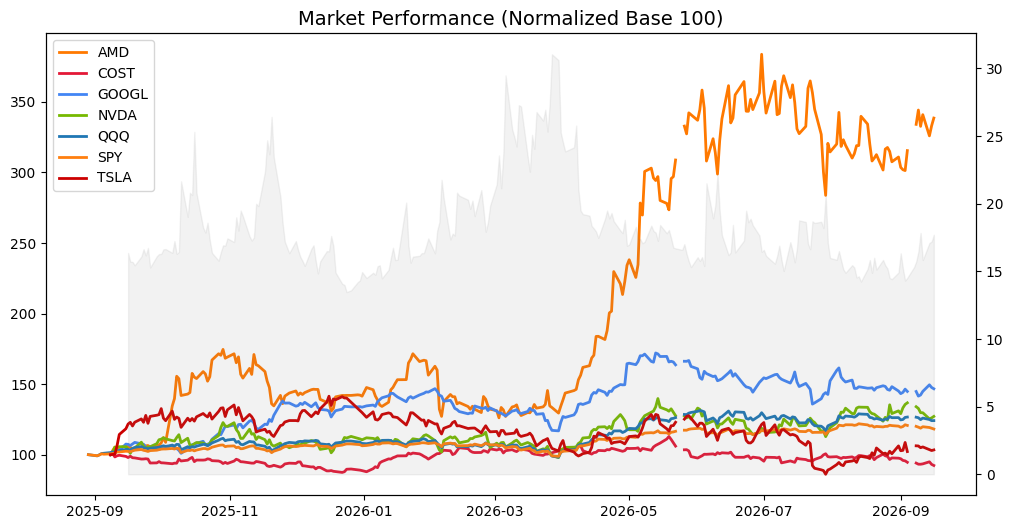

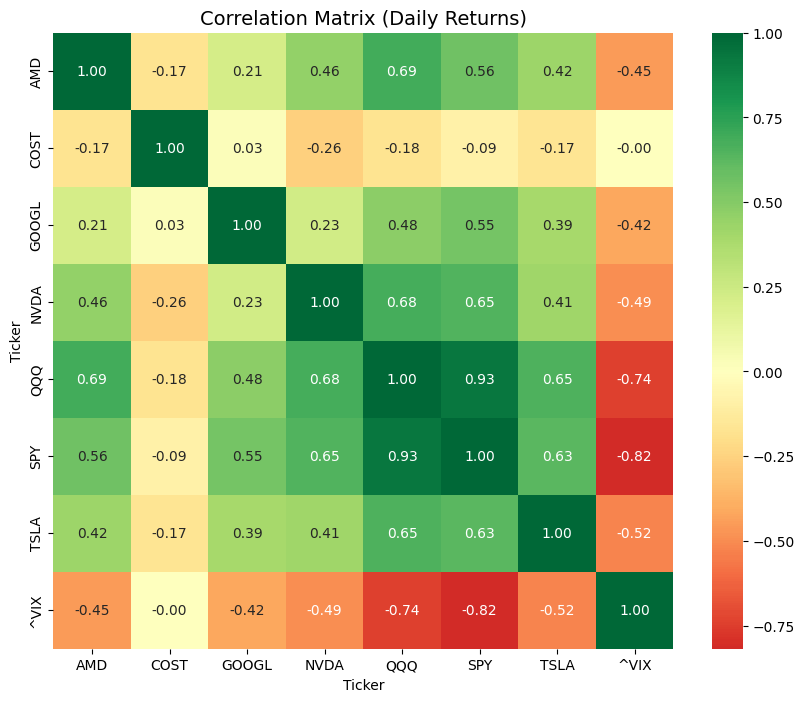

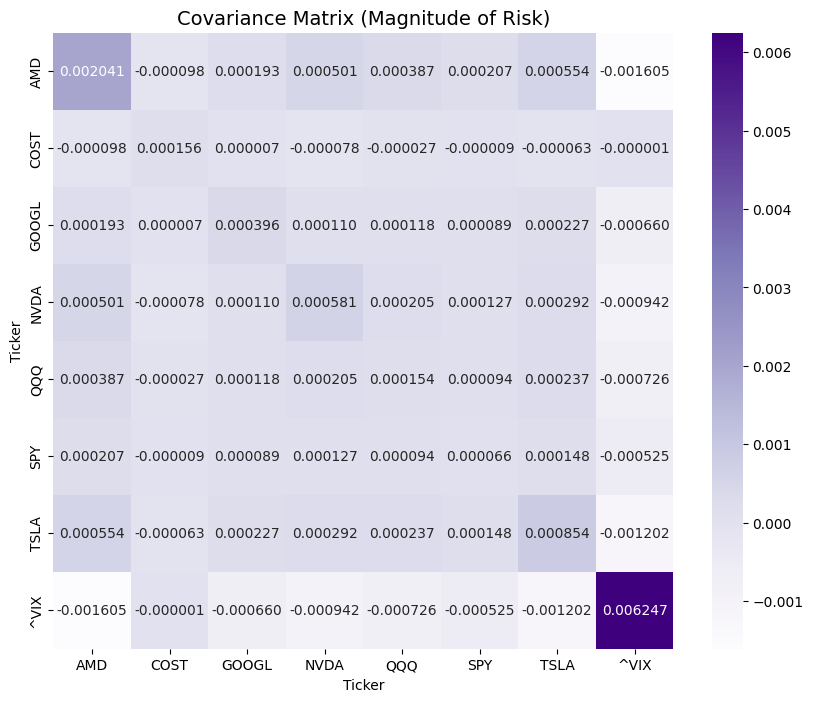


STATISTICAL SUMMARY

Top Correlations with VIX:
Ticker
SPY     -0.818552
QQQ     -0.740990
TSLA    -0.520449
NVDA    -0.494495
AMD     -0.449482
GOOGL   -0.419858
COST    -0.001227
^VIX     1.000000
Name: ^VIX, dtype: float64

Average Daily Volatility (Std Dev of Returns):
Ticker
^VIX     0.079041
AMD      0.045174
TSLA     0.029221
NVDA     0.024104
GOOGL    0.019888
COST     0.012502
QQQ      0.012396
SPY      0.008122
dtype: float64


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming 'prices' is your existing DataFrame with columns: [Date, Ticker, Price]

def plot_market_trends(df):
    """
    Analyzes and visualizes stock performance, correlation, and covariance.
    """
    # 1. Data Preparation
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Pivot from Long to Wide format for analysis
    pivot_df = df.pivot(index='Date', columns='Ticker', values='Price').sort_index()
    
    # Separate stocks from the volatility index
    tickers = [c for c in pivot_df.columns if c != '^VIX']
    
    # 2. Calculate Returns (Required for Corr/Covar)
    # We use percentage change (daily returns) rather than raw prices 
    # to avoid "spurious correlation" driven by absolute price levels.
    returns_df = pivot_df.pct_change().dropna()

    # 3. Compute Matrices
    corr_matrix = returns_df.corr()
    cov_matrix = returns_df.cov()

    # --- VISUALIZATION ---

    # A. Performance Plot (Relative Returns)
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()
    colors = {'GOOGL': '#4285F4', 'COST': '#E31837', 'NVDA': '#76B900', 'TSLA': '#CC0000', 'AMD': '#FF7900'}

    for ticker in tickers:
        normalized_series = (pivot_df[ticker] / pivot_df[ticker].dropna().iloc[0] * 100)
        ax1.plot(normalized_series.index, normalized_series, 
                 label=f"{ticker}", color=colors.get(ticker), linewidth=2)

    if '^VIX' in pivot_df.columns:
        ax2.fill_between(pivot_df.index, pivot_df['^VIX'], color='gray', alpha=0.1, label='VIX')
    
    ax1.set_title("Market Performance (Normalized Base 100)", fontsize=14)
    ax1.legend(loc='upper left')
    plt.show()

    # B. Correlation Matrix Heatmap
    # Shows -1 (perfect opposite) to +1 (perfect sync)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt=".2f")
    plt.title("Correlation Matrix (Daily Returns)", fontsize=14)
    plt.show()

    # C. Covariance Matrix Heatmap
    # Shows the magnitude of shared variance (Volatility * Correlation)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cov_matrix, annot=True, cmap='Purples', fmt=".6f")
    plt.title("Covariance Matrix (Magnitude of Risk)", fontsize=14)
    plt.show()

    # 4. Statistical Summary Printout
    print("\n" + "="*30)
    print("STATISTICAL SUMMARY")
    print("="*30)
    print("\nTop Correlations with VIX:")
    if '^VIX' in corr_matrix.columns:
        print(corr_matrix['^VIX'].sort_values())
    
    print("\nAverage Daily Volatility (Std Dev of Returns):")
    print(returns_df.std().sort_values(ascending=False))

# Execution call:
plot_market_trends(prices)

## Evaluating the Sentiment Over time

In [22]:
news['Processed'].value_counts()

Processed
1    5981
0     400
Name: count, dtype: int64

In [ ]:
import sqlite3
import pandas as pd
import requests
import json
import re
import numpy as np
import os
try:
    from json_repair import repair_json as repair1
except ImportError:
    try:
        from json_repair import repair
    except ImportError:
        def repair(s): return s 
from tqdm import tqdm

# --- Configuration ---
DB_NAME = "/home/erfontes/research/trader/market_data.db"
MODEL_NAME = "gemma4:31b" 
OLLAMA_URL = "http://127.0.0.1:11434/api/generate"
NUM_VOTES = 15      # 15 parallel votes for fast & robust consensus
DEFAULT_TEMP = 0.3

def init_db_tables(conn):
    """Ensures that the sentiment_results table exists and includes Materiality_Score."""
    conn.execute("""
        CREATE TABLE IF NOT EXISTS sentiment_results (
            NewsID TEXT PRIMARY KEY,
            Ticker TEXT,
            Date TEXT,
            Sentiment_Label TEXT,
            Median_Intensity REAL,
            Disagreement_Std REAL,
            Vote_Count INTEGER,
            Materiality_Score REAL DEFAULT 0.7,
            Created_At TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        )
    """)
    try:
        conn.execute("ALTER TABLE sentiment_results ADD COLUMN Materiality_Score REAL DEFAULT 0.7")
    except Exception:
        pass # Column already exists
    conn.execute("CREATE INDEX IF NOT EXISTS idx_sentiment_ticker_date ON sentiment_results (Ticker, Date)")
    conn.commit()

def extract_sentiment_payload(raw_result):
    """Robustly extracts sentiment and materiality floats from LLM response."""
    if not isinstance(raw_result, dict):
        return None, None
    raw_text = raw_result.get('thinking') or raw_result.get('response', '{}')
    try:
        repaired = repair(raw_text)
        data = json.loads(repaired)
        sent = float(data.get('sentiment', 0.0))
        mat = float(data.get('materiality', data.get('materiality_score', 0.7)))
        return sent, mat
    except (json.JSONDecodeError, ValueError, TypeError):
        sent_m = re.search(r'"sentiment":\s*(-?\d*\.?\d+)', raw_text)
        mat_m = re.search(r'"materiality(?:_score)?":\s*(\d*\.?\d+)', raw_text)
        sent = float(sent_m.group(1)) if sent_m else None
        mat = float(mat_m.group(1)) if mat_m else 0.7
        return sent, mat

def fetch_sentiment_consensus(ticker, title, summary):
    """Queries Gemma 4 concurrently to extract consensus sentiment and catalyst materiality."""
    import concurrent.futures
    
    prompt = f"""
    Analyze financial market news for {ticker}.
    Headline: {title}
    Summary: {summary}

    Evaluate both Sentiment and Catalyst Materiality.
    - sentiment: float from -1.0 (extremely bearish) to +1.0 (extremely bullish).
    - materiality: float from 0.0 (vague speculation/opinion/listicle/no hard catalyst) to 1.0 (hard corporate catalyst: earnings surprise, M&A, FDA approval, official guidance, SEC filing).
    - confidence: float from 0.0 to 1.0.

    Return ONLY JSON:
    {{"sentiment": float, "materiality": float, "confidence": float, "reason": "string"}}
    """
    payload = {
        "model": MODEL_NAME, 
        "prompt": prompt, 
        "stream": False, 
        "format": "json", 
        "options": {"temperature": DEFAULT_TEMP}
    }

    def single_vote():
        try:
            response = requests.post(OLLAMA_URL, json=payload, timeout=60)
            sent, mat = extract_sentiment_payload(response.json())
            return sent, mat
        except Exception: 
            return None, None

    sent_votes = []
    mat_votes = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=5) as executor:
        futures = [executor.submit(single_vote) for _ in range(NUM_VOTES)]
        for future in concurrent.futures.as_completed(futures):
            s_val, m_val = future.result()
            if s_val is not None:
                sent_votes.append(s_val)
            if m_val is not None:
                mat_votes.append(m_val)
            
    if not sent_votes: 
        return None, None, 0, 0.7
        
    median_sent = float(np.median(sent_votes))
    std_sent = float(np.std(sent_votes))
    median_mat = float(np.median(mat_votes)) if mat_votes else 0.7
    return median_sent, std_sent, len(sent_votes), median_mat

def run_daily_aggregation():
    """Processes unprocessed news with Quality & Materiality scoring, storing in DB."""
    if not os.path.exists(DB_NAME):
        print(f"❌ Error: Database not found at {DB_NAME}")
        return None

    conn = sqlite3.connect(DB_NAME)
    init_db_tables(conn)
    
    query = "SELECT NewsID, Ticker, Date, Title, Summary FROM news WHERE Processed = 0"
    df_news = pd.read_sql(query, conn)
    
    if df_news.empty:
        print("📭 No new news items to process.")
        conn.close()
        return None

    print(f"🚀 Consensus Analysis ({NUM_VOTES} votes) on RTX 4090 using {MODEL_NAME} (with Materiality Filter)...")
    session_results = []
    
    for _, row in tqdm(df_news.iterrows(), total=len(df_news), desc="Analyzing Sentiment & Materiality"):
        median_val, std_val, actual_votes, mat_val = fetch_sentiment_consensus(row['Ticker'], row['Title'], row['Summary'])
        
        if median_val is not None:
            label = "Positive" if median_val > 0 else "Negative" if median_val < 0 else "Neutral"
            date_clean = pd.to_datetime(row['Date']).strftime('%Y-%m-%d')
            
            try:
                conn.execute("""
                    INSERT OR REPLACE INTO sentiment_results 
                    (NewsID, Ticker, Date, Sentiment_Label, Median_Intensity, Disagreement_Std, Vote_Count, Materiality_Score)
                    VALUES (?, ?, ?, ?, ?, ?, ?, ?)
                """, (row['NewsID'], row['Ticker'], date_clean, label, median_val, std_val, actual_votes, mat_val))
                
                conn.execute("UPDATE news SET Processed = 1 WHERE NewsID = ? ", (row['NewsID'],))
                conn.commit()
            except Exception as e:
                print(f"DB Error for {row['NewsID']}: {e}")

            session_results.append({
                "Date": date_clean,
                "Ticker": row['Ticker'],
                "Sentiment": label,
                "Value": median_val,
                "Disagreement": std_val,
                "Materiality": mat_val
            })

    conn.close()

    if not session_results: 
        return None

    df_results = pd.DataFrame(session_results)
    
    summary = df_results.groupby(['Date', 'Ticker']).agg({
        'Value': ['mean', 'median', 'std'],
        'Disagreement': 'mean',
        'Materiality': 'mean'
    }).reset_index()
    
    summary.columns = ['Date', 'Ticker', 'Avg_Intensity', 'Median_Intensity', 'Intensity_Std', 'Avg_Disagreement', 'Avg_Materiality']
    
    counts = df_results[df_results['Sentiment'] != 'Neutral'].groupby(['Date', 'Ticker', 'Sentiment']).size().unstack(fill_value=0)
    for col in ['Positive', 'Negative']:
        if col not in counts.columns: counts[col] = 0
    
    final_table = summary.merge(counts, on=['Date', 'Ticker'], how='left')
    final_table['Net_Count'] = final_table['Positive'] - final_table['Negative']
    
    return final_table

if __name__ == "__main__":
    table = run_daily_aggregation()
    if table is not None:
        output_csv = "/home/erfontes/research/trader/ticker_sentiment_daily_summary.csv"
        table.to_csv(output_csv, index=False)
        print(f"📁 Sentiment summary updated: {output_csv}")


🚀 Consensus Analysis (15 votes) on RTX 4090 using gemma4:31b (with Materiality Filter)...


Analyzing Sentiment & Materiality:   0%|          | 0/400 [00:00<?, ?it/s]

Analyzing Sentiment & Materiality:   0%|          | 1/400 [02:15<15:00:28, 135.41s/it]

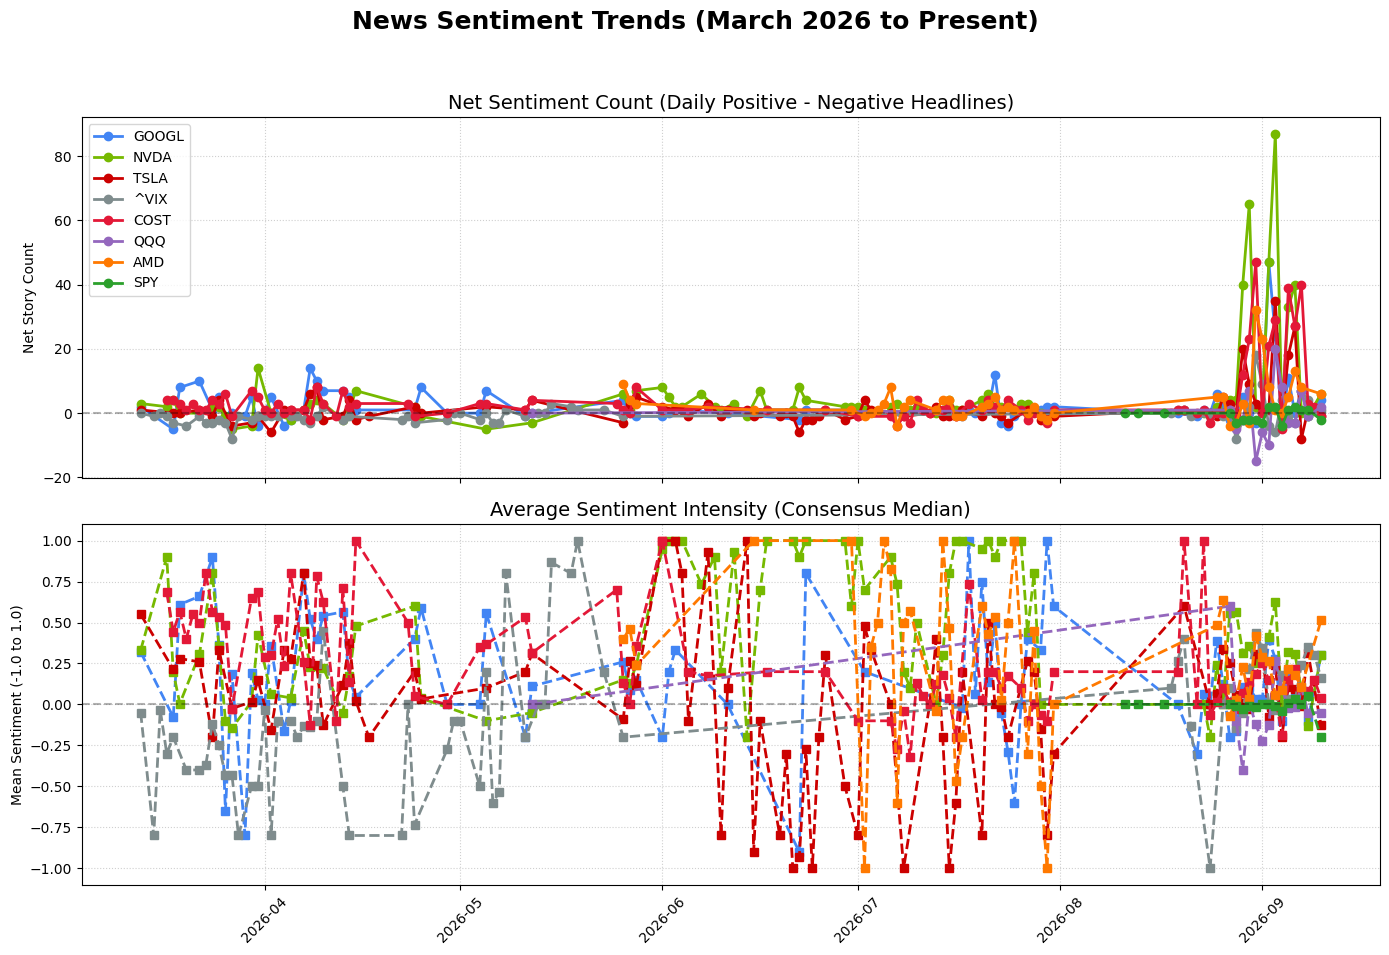

✅ Successfully plotted trends from 471 daily ticker records (starting 2026-03-01).


In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configuration ---
DB_NAME = "/home/erfontes/research/trader/market_data.db"

TICKER_COLORS = {
    'GOOGL': '#4285F4', 
    'COST': '#E31837', 
    'NVDA': '#76B900', 
    'TSLA': '#CC0000',
    '^VIX': '#7F8C8D',
    'AMD' : '#FF7900',
    'SPY' : '#2CA02C',
    'QQQ' : '#9467BD'
}

def load_data_from_db(start_date="2026-03-01"):
    """Queries and aggregates sentiment data directly from SQLite starting from Mar 2026."""
    if not os.path.exists(DB_NAME):
        raise FileNotFoundError(f"Database not found at {DB_NAME}")

    conn = sqlite3.connect(DB_NAME)
    
    # Filter by start_date to exclude ancient/outlier news records (e.g. 2019-2023)
    query = f"""
    SELECT 
        Date, 
        Ticker, 
        SUM(CASE WHEN Sentiment_Label = 'Positive' THEN 1 ELSE 0 END) as Positive,
        SUM(CASE WHEN Sentiment_Label = 'Negative' THEN 1 ELSE 0 END) as Negative,
        AVG(Median_Intensity) as Avg_Intensity

        
    FROM sentiment_results
    WHERE Date >= '{start_date}'
    GROUP BY Date, Ticker
    ORDER BY Date ASC
    """
    
    df = pd.read_sql(query, conn)
    conn.close()
    
    # Calculate Net_Count (Breadth)
    df['Net_Count'] = df['Positive'] - df['Negative']
    df['Date'] = pd.to_datetime(df['Date'])
    
    return df

def plot_sentiment_trends(start_date="2026-03-01"):
    try:
        # 1. Load the data from DB (Filtered to start from Mar 2026)
        df = load_data_from_db(start_date=start_date)
        
        if df.empty:
            print(f"📭 No data found in the 'sentiment_results' table after {start_date}.")
            return

        # 2. Setup the figure
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
        fig.suptitle(f'News Sentiment Trends (March 2026 to Present)', fontsize=18, fontweight='bold')

        # 3. Plot Net Count (Breadth)
        for ticker in df['Ticker'].unique():
            ticker_data = df[df['Ticker'] == ticker]
            ax1.plot(ticker_data['Date'], ticker_data['Net_Count'], 
                     marker='o', label=ticker, color=TICKER_COLORS.get(ticker, None), linewidth=2)
        
        ax1.set_title('Net Sentiment Count (Daily Positive - Negative Headlines)', fontsize=14)
        ax1.set_ylabel('Net Story Count')
        ax1.axhline(0, color='black', linestyle='--', alpha=0.3)
        ax1.grid(True, linestyle=':', alpha=0.6)
        ax1.legend(loc='upper left', frameon=True)

        # 4. Plot Average Intensity (Depth)
        for ticker in df['Ticker'].unique():
            ticker_data = df[df['Ticker'] == ticker]
            ax2.plot(ticker_data['Date'], ticker_data['Avg_Intensity'], 
                     marker='s', label=ticker, color=TICKER_COLORS.get(ticker, None), linewidth=2, linestyle='--')

        ax2.set_title('Average Sentiment Intensity (Consensus Median)', fontsize=14)
        ax2.set_ylabel('Mean Sentiment (-1.0 to 1.0)')
        ax2.axhline(0, color='black', linestyle='--', alpha=0.3)
        ax2.grid(True, linestyle=':', alpha=0.6)

        # 5. Formatting
        plt.xticks(rotation=45)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
        plt.show()
        print(f"✅ Successfully plotted trends from {len(df)} daily ticker records (starting {start_date}).")
        
    except Exception as e:
        print(f"❌ Plotting Error: {e}")

if __name__ == "__main__":
    plot_sentiment_trends(start_date="2026-03-01")


## Creating the Traninig Data

In [10]:
import sqlite3
import pandas as pd
import numpy as np

# --- Configuration ---
DB_NAME = "/home/erfontes/research/trader/market_data.db"
OUTPUT_FILE = "/home/erfontes/research/trader/stock_training_data_v1.csv"

def create_training_dataset(sent_df=None):
    """
    Merges price data with macro benchmarks (SPY, QQQ, VIX) and all historical
    sentiment data from SQLite, generating binary direction and excess returns.
    """
    # 1. Load Price Data from SQLite
    conn = sqlite3.connect(DB_NAME)
    price_df = pd.read_sql("SELECT * FROM prices", conn)
    conn.close()
    
    price_df['Date'] = pd.to_datetime(price_df['Date'])
    price_df = price_df.sort_values(['Date', 'Ticker'])

    # 2. Extract Macro Benchmark Features (VIX, SPY, QQQ)
    vix_df = price_df[price_df['Ticker'] == '^VIX'][['Date', 'Price']].rename(columns={'Price': 'VIX_Close'})
    vix_df['VIX_Daily_Change'] = vix_df['VIX_Close'].pct_change()
    
    spy_df = price_df[price_df['Ticker'] == 'SPY'][['Date', 'Price']].rename(columns={'Price': 'SPY_Close'})
    spy_df['SPY_Return'] = spy_df['SPY_Close'].pct_change()
    
    qqq_df = price_df[price_df['Ticker'] == 'QQQ'][['Date', 'Price']].rename(columns={'Price': 'QQQ_Close'})
    qqq_df['QQQ_Return'] = qqq_df['QQQ_Close'].pct_change()

    # 3. Individual stock targets (exclude macro benchmarks from being traded targets)
    macro_tickers = ['^VIX', 'SPY', 'QQQ']
    stock_df = price_df[~price_df['Ticker'].isin(macro_tickers)].copy()
    stock_df['Target_Price'] = stock_df.groupby('Ticker')['Price'].shift(-1)
    stock_df['Target'] = (stock_df['Target_Price'] > stock_df['Price']).astype(int)
    stock_df['Daily_Return'] = stock_df.groupby('Ticker')['Price'].pct_change()

    # 4. Handle Sentiment Data (pull all historical sentiment directly from DB)
    if sent_df is None:
        try:
            conn_sent = sqlite3.connect(DB_NAME)
            s_raw = pd.read_sql("SELECT Date, Ticker, Sentiment_Label as Sentiment, Median_Intensity as Value, Disagreement_Std as Disagreement FROM sentiment_results", conn_sent)
            conn_sent.close()
            s_raw['Date'] = pd.to_datetime(s_raw['Date']).dt.strftime('%Y-%m-%d')
            summary = s_raw.groupby(['Date', 'Ticker']).agg({'Value': ['mean', 'median', 'std'], 'Disagreement': 'mean'}).reset_index()
            summary.columns = ['Date', 'Ticker', 'Avg_Intensity', 'Median_Intensity', 'Intensity_Std', 'Avg_Disagreement']
            counts = s_raw[s_raw['Sentiment'] != 'Neutral'].groupby(['Date', 'Ticker', 'Sentiment']).size().unstack(fill_value=0)
            for col in ['Positive', 'Negative']:
                if col not in counts.columns:
                    counts[col] = 0
            sent_df = summary.merge(counts, on=['Date', 'Ticker'], how='left').fillna({'Positive': 0, 'Negative': 0})
            sent_df['Net_Count'] = sent_df['Positive'] - sent_df['Negative']
            sent_df['Date'] = pd.to_datetime(sent_df['Date'])
            sent_df.to_csv("/home/erfontes/research/trader/ticker_sentiment_daily_summary.csv", index=False)
        except Exception:
            try:
                sent_df = pd.read_csv("/home/erfontes/research/trader/ticker_sentiment_daily_summary.csv")
                sent_df['Date'] = pd.to_datetime(sent_df['Date'])
            except FileNotFoundError:
                sent_df = pd.DataFrame(columns=['Date', 'Ticker'])
    else:
        sent_df = sent_df.reset_index()
        sent_df['Date'] = pd.to_datetime(sent_df['Date'])

    # 5. Merge Features
    master_df = stock_df.copy()
    master_df = pd.merge(master_df, vix_df, on='Date', how='left')
    master_df = pd.merge(master_df, spy_df, on='Date', how='left')
    master_df = pd.merge(master_df, qqq_df, on='Date', how='left')
    master_df = pd.merge(master_df, sent_df, on=['Date', 'Ticker'], how='left')

    # 6. Cleaning & Alpha Factor Engineering
    fill_cols = ['Positive', 'Negative', 'Net_Count', 'Avg_Intensity']
    for col in fill_cols:
        if col in master_df.columns:
            master_df[col] = master_df[col].fillna(0)
    
    # Excess Return (Stock return minus S&P 500 benchmark)
    master_df['Excess_Return'] = master_df['Daily_Return'] - master_df['SPY_Return']

    train_ready = master_df.dropna(subset=['Target', 'Daily_Return'])

    # 7. Final selection of columns
    available_cols = [
        'Date', 'Ticker', 'Price', 'Daily_Return',
        'SPY_Close', 'SPY_Return', 'QQQ_Close', 'QQQ_Return', 'Excess_Return',
        'VIX_Close', 'VIX_Daily_Change',
        'Positive', 'Negative', 'Net_Count', 'Avg_Intensity',
        'Target'
    ]
    cols_to_keep = [c for c in available_cols if c in train_ready.columns]
    final_df = train_ready[cols_to_keep]
    
    final_df.to_csv(OUTPUT_FILE, index=False)
    print(f"✅ Training data generated with {len(final_df)} records including SPY and QQQ macro features.")
    return final_df

if __name__ == "__main__":
    training_df = create_training_dataset()
    if training_df is not None:
        print("--- Final Training Data Snapshot ---")
        print(training_df.tail())


✅ Training data generated with 1280 records including SPY and QQQ macro features.
--- Final Training Data Snapshot ---
           Date Ticker       Price  Daily_Return   SPY_Close  SPY_Return  \
1280 2026-09-15    AMD  504.200012      0.021868  757.390015   -0.004587   
1281 2026-09-15   COST  901.349976     -0.019110  757.390015   -0.004587   
1282 2026-09-15  GOOGL  344.980011     -0.012622  757.390015   -0.004587   
1283 2026-09-15   NVDA  212.169998      0.005736  757.390015   -0.004587   
1284 2026-09-15   TSLA  356.579987     -0.006658  757.390015   -0.004587   

       QQQ_Close  QQQ_Return  Excess_Return  VIX_Close  VIX_Daily_Change  \
1280  704.539978   -0.006543       0.026455  17.200001          0.005848   
1281  704.539978   -0.006543      -0.014523  17.200001          0.005848   
1282  704.539978   -0.006543      -0.008035  17.200001          0.005848   
1283  704.539978   -0.006543       0.010322  17.200001          0.005848   
1284  704.539978   -0.006543      -0.002071 

## Inital Model Pass

In [11]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from lightgbm import LGBMClassifier

# 1. Load the generated dataset
df = pd.read_csv("stock_training_data_v1.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Date', 'Ticker']).reset_index(drop=True)

# Exclude ^VIX from being predicted as a stock (keep it as a macro feature)
trade_df = df[df['Ticker'] != '^VIX'].copy()

# 2. Select Features
feature_cols = [
    'Daily_Return', 
    'VIX_Close', 
    'VIX_Daily_Change',
    'Positive', 
    'Negative', 
    'Net_Count', 
    'Avg_Intensity'
]
target_col = 'Target'

# 3. Chronological Time-Series Split (80% Train, 20% Test)
split_idx = int(len(trade_df['Date'].unique()) * 0.80)
split_date = trade_df['Date'].unique()[split_idx]

train_data = trade_df[trade_df['Date'] < split_date]
test_data = trade_df[trade_df['Date'] >= split_date]

X_train, y_train = train_data[feature_cols], train_data[target_col]
X_test, y_test = test_data[feature_cols], test_data[target_col]

print(f"📅 Train range: {train_data['Date'].min().date()} to {train_data['Date'].max().date()} ({len(train_data)} rows)")
print(f"📅 Test range:  {test_data['Date'].min().date()} to {test_data['Date'].max().date()} ({len(test_data)} rows)")

# 4. Train Model 1: Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=4, min_samples_leaf=5, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

# 5. Train Model 2: LightGBM
lgbm = LGBMClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
lgbm_preds = lgbm.predict(X_test)
lgbm_probs = lgbm.predict_proba(X_test)[:, 1]

# 6. Evaluation
print("\n" + "="*45)
print(f"🌲 Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.2%} | ROC-AUC: {roc_auc_score(y_test, rf_probs):.3f}")
print(f"⚡ LightGBM Accuracy:      {accuracy_score(y_test, lgbm_preds):.2%} | ROC-AUC: {roc_auc_score(y_test, lgbm_probs):.3f}")
print("="*45)

# 7. Feature Importances (What drove the decisions?)
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'RF_Importance': rf.feature_importances_,
    'LGBM_Importance': lgbm.feature_importances_
}).sort_values(by='RF_Importance', ascending=False)

print("\n--- Feature Importances ---")
print(importance_df.to_string(index=False))


📅 Train range: 2025-09-09 to 2026-07-01 (1020 rows)
📅 Test range:  2026-07-02 to 2026-09-15 (260 rows)

🌲 Random Forest Accuracy: 50.38% | ROC-AUC: 0.476
⚡ LightGBM Accuracy:      53.85% | ROC-AUC: 0.516

--- Feature Importances ---
         Feature  RF_Importance  LGBM_Importance
VIX_Daily_Change       0.317708              126
       VIX_Close       0.220098              116
    Daily_Return       0.169969               73
   Avg_Intensity       0.100482               26
       Net_Count       0.097540               37
        Positive       0.050821               17
        Negative       0.043382                2


In [12]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# -------------------------------------------------------------
# 1. Load Data & Ensure Clean Sorting
# -------------------------------------------------------------
df = pd.read_csv("stock_training_data_v1.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# -------------------------------------------------------------
# 2. Advanced Feature Engineering
# -------------------------------------------------------------
# A. RSI (14-day Relative Strength Index)
def calc_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period, min_periods=period).mean()
    avg_loss = loss.rolling(period, min_periods=period).mean()
    rs = avg_gain / (avg_loss + 1e-9)
    return (100 - (100 / (1 + rs))).fillna(50)

df['RSI_14'] = df.groupby('Ticker')['Price'].transform(calc_rsi)

# B. Moving Average Distance (Mean-Reversion / Overbought Signals)
df['SMA_5_dist'] = df.groupby('Ticker')['Price'].transform(lambda s: (s / s.rolling(5, min_periods=1).mean()) - 1).fillna(0)
df['SMA_20_dist'] = df.groupby('Ticker')['Price'].transform(lambda s: (s / s.rolling(20, min_periods=1).mean()) - 1).fillna(0)

# C. Multi-day Returns & Volatility
df['Return_3d'] = df.groupby('Ticker')['Price'].pct_change(3).fillna(0)
df['Return_5d'] = df.groupby('Ticker')['Price'].pct_change(5).fillna(0)
df['Vol_10d'] = df.groupby('Ticker')['Daily_Return'].transform(lambda s: s.rolling(10, min_periods=1).std()).fillna(0)

# D. LLM Sentiment Momentum & Divergence Signals
# 3-day smoothed sentiment (persistence)
df['Sent_Rolling_3d'] = df.groupby('Ticker')['Avg_Intensity'].transform(lambda s: s.rolling(3, min_periods=1).mean()).fillna(0)

# Sentiment Divergence: Positive news on a dip = high probability bounce catalyst
df['Sent_Divergence'] = (df['Avg_Intensity'] - df['Daily_Return']).fillna(0)

# Total News Volume
df['News_Volume'] = df['Positive'] + df['Negative']

# Sort chronologically for modeling
df = df.sort_values(['Date', 'Ticker']).reset_index(drop=True)
trade_df = df[df['Ticker'] != '^VIX'].copy()

# -------------------------------------------------------------
# 3. Feature Definitions
# -------------------------------------------------------------
enhanced_features = [
    'Daily_Return', 'Return_3d', 'Return_5d', 
    'SMA_5_dist', 'SMA_20_dist', 'RSI_14', 'Vol_10d', 
    'SPY_Return', 'QQQ_Return', 'Excess_Return',
    'VIX_Close', 'VIX_Daily_Change',
    'Positive', 'Negative', 'Net_Count', 'Avg_Intensity', 
    'Sent_Rolling_3d', 'Sent_Divergence', 'News_Volume'
]

# -------------------------------------------------------------
# 4. Out-of-Sample Chronological Split (80% Train, 20% Test)
# -------------------------------------------------------------
split_idx = int(len(trade_df['Date'].unique()) * 0.80)
split_date = trade_df['Date'].unique()[split_idx]

train_d = trade_df[trade_df['Date'] < split_date]
test_d = trade_df[trade_df['Date'] >= split_date]

print(f"📅 Training Period: {train_d['Date'].min().date()} to {train_d['Date'].max().date()} ({len(train_d)} rows)")
print(f"📅 Testing Period:  {test_d['Date'].min().date()} to {test_d['Date'].max().date()} ({len(test_d)} rows)")

# -------------------------------------------------------------
# 5. Model Training: Random Forest & LightGBM
# -------------------------------------------------------------
# Model 1: Random Forest with Enhanced Features
rf = RandomForestClassifier(n_estimators=150, max_depth=4, min_samples_leaf=8, random_state=42)
rf.fit(train_d[enhanced_features], train_d['Target'])
rf_preds = rf.predict(test_d[enhanced_features])
rf_probs = rf.predict_proba(test_d[enhanced_features])[:, 1]

# Model 2: LightGBM with Regularization
lgb = LGBMClassifier(n_estimators=80, max_depth=3, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, min_child_samples=15, random_state=42, verbose=-1)
lgb.fit(train_d[enhanced_features], train_d['Target'])
lgb_preds = lgb.predict(test_d[enhanced_features])
lgb_probs = lgb.predict_proba(test_d[enhanced_features])[:, 1]

# -------------------------------------------------------------
# 6. Evaluation & Comparison
# -------------------------------------------------------------
print("\n" + "="*55)
print("📊 MODEL PERFORMANCE (OUT-OF-SAMPLE TEST SET)")
print("="*55)
print(f"🌲 Random Forest (Enhanced): Accuracy: {accuracy_score(test_d['Target'], rf_preds):.2%} | ROC-AUC: {roc_auc_score(test_d['Target'], rf_probs):.3f}")
print(f"⚡ LightGBM (Enhanced):      Accuracy: {accuracy_score(test_d['Target'], lgb_preds):.2%} | ROC-AUC: {roc_auc_score(test_d['Target'], lgb_probs):.3f}")

# -------------------------------------------------------------
# 7. Selective Trading: High-Conviction Filter
# -------------------------------------------------------------
print("\n" + "-"*55)
print("🎯 SELECTIVE TRADING: HIGH-CONVICTION BETS")
print("-"*55)

for threshold in [0.54, 0.56, 0.58]:
    lower_bound = 1.0 - threshold
    mask = (rf_probs >= threshold) | (rf_probs <= lower_bound)
    if mask.sum() > 0:
        filtered_preds = (rf_probs[mask] >= 0.5).astype(int)
        win_rate = accuracy_score(test_d[mask]['Target'], filtered_preds)
        print(f"Confidence >= {threshold:.0%} or <= {lower_bound:.0%}:  Trades: {mask.sum():3d}/{len(test_d)} | Win Rate: {win_rate:.2%}")

# -------------------------------------------------------------
# 8. Feature Importance Breakdown
# -------------------------------------------------------------
importance_df = pd.DataFrame({
    'Feature': enhanced_features,
    'RF_Importance': rf.feature_importances_,
    'LGBM_Importance': lgb.feature_importances_
}).sort_values('RF_Importance', ascending=False)

print("\n--- 🔍 Top Feature Importances ---")
print(importance_df.head(10).to_string(index=False))


# -------------------------------------------------------------
# 9. Accuracy Breakdown by Stock (Ticker)
# -------------------------------------------------------------
print("\n" + "="*65)
print("📈 OUT-OF-SAMPLE PERFORMANCE BREAKDOWN BY STOCK")
print("="*65)

test_eval = test_d.copy()
test_eval['RF_Pred'] = rf_preds
test_eval['LGB_Pred'] = lgb_preds
test_eval['LGB_Prob'] = lgb_probs

stock_rows = []
for t, grp in test_eval.groupby('Ticker'):
    stock_rows.append({
        'Ticker': t,
        'Test Days': len(grp),
        'Actual Up Days': f"{grp['Target'].sum()}/{len(grp)} ({grp['Target'].mean():.1%})",
        'RF Accuracy': f"{accuracy_score(grp['Target'], grp['RF_Pred']):.1%}",
        'LightGBM Accuracy': f"{accuracy_score(grp['Target'], grp['LGB_Pred']):.1%}",
        'LGBM ROC-AUC': f"{roc_auc_score(grp['Target'], grp['LGB_Prob']):.3f}" if len(grp['Target'].unique()) > 1 else "N/A"
    })

stock_summary_df = pd.DataFrame(stock_rows)
print(stock_summary_df.to_string(index=False))


📅 Training Period: 2025-09-09 to 2026-07-01 (1020 rows)
📅 Testing Period:  2026-07-02 to 2026-09-15 (260 rows)

📊 MODEL PERFORMANCE (OUT-OF-SAMPLE TEST SET)
🌲 Random Forest (Enhanced): Accuracy: 50.77% | ROC-AUC: 0.523
⚡ LightGBM (Enhanced):      Accuracy: 54.23% | ROC-AUC: 0.514

-------------------------------------------------------
🎯 SELECTIVE TRADING: HIGH-CONVICTION BETS
-------------------------------------------------------
Confidence >= 54% or <= 46%:  Trades:  90/260 | Win Rate: 54.44%
Confidence >= 56% or <= 44%:  Trades:  50/260 | Win Rate: 56.00%
Confidence >= 58% or <= 42%:  Trades:  21/260 | Win Rate: 42.86%

--- 🔍 Top Feature Importances ---
         Feature  RF_Importance  LGBM_Importance
VIX_Daily_Change       0.141070               56
       Return_5d       0.103121               37
       VIX_Close       0.100150               72
      SPY_Return       0.099309               36
      SMA_5_dist       0.077953                9
      QQQ_Return       0.074066         

In [13]:
import pandas as pd
import numpy as np
import time
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("="*65)
print("🚀 HYPERPARAMETER OPTIMIZATION & ENSEMBLE TUNING")
print("="*65)

# -------------------------------------------------------------
# 1. Setup Time-Series Cross Validation (Expanding Window)
# -------------------------------------------------------------
# Standard K-Fold leaks future data in financial time-series.
# TimeSeriesSplit ensures we only train on the past to validate the future.
tscv = TimeSeriesSplit(n_splits=4)
print(f"📊 Using TimeSeriesSplit with {tscv.n_splits} expanding chronological folds.")

# -------------------------------------------------------------
# 2. LightGBM Hyperparameter Search
# -------------------------------------------------------------
print("\n🔍 [1/2] Optimizing LightGBM hyperparameters via TimeSeriesSplit CV...")
t0 = time.time()
lgbm_param_grid = {
    'n_estimators': [30, 50, 80],
    'max_depth': [2, 3],
    'learning_rate': [0.02, 0.04],
    'colsample_bytree': [0.6, 0.8],
    'reg_alpha': [0.0, 0.5],
    'reg_lambda': [0.5, 1.0]
}

grid_lgb = GridSearchCV(
    estimator=LGBMClassifier(n_jobs=1, random_state=42, verbose=-1),
    param_grid=lgbm_param_grid,
    cv=tscv,
    scoring='roc_auc',
    n_jobs=4
)
grid_lgb.fit(train_d[enhanced_features], train_d['Target'])
best_lgb = grid_lgb.best_estimator_

print(f"   ⏱️ LightGBM tuning done in {time.time() - t0:.1f}s | Best CV ROC-AUC: {grid_lgb.best_score_:.3f}")
print(f"   Optimal Params: {grid_lgb.best_params_}")

# -------------------------------------------------------------
# 3. Random Forest Hyperparameter Search
# -------------------------------------------------------------
print("\n🔍 [2/2] Optimizing Random Forest hyperparameters via TimeSeriesSplit CV...")
t1 = time.time()
rf_param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [3, 4],
    'min_samples_leaf': [8, 12],
    'max_features': ['sqrt', 0.6]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=tscv,
    scoring='roc_auc',
    n_jobs=4
)
grid_rf.fit(train_d[enhanced_features], train_d['Target'])
best_rf = grid_rf.best_estimator_

print(f"   ⏱️ Random Forest tuning done in {time.time() - t1:.1f}s | Best CV ROC-AUC: {grid_rf.best_score_:.3f}")
print(f"   Optimal Params: {grid_rf.best_params_}")

# -------------------------------------------------------------
# 4. Out-of-Sample Predictions (Tuned Models & Ensemble)
# -------------------------------------------------------------
test_eval = test_d.copy()

# Tuned LightGBM predictions
test_eval['LGB_Prob'] = best_lgb.predict_proba(test_d[enhanced_features])[:, 1]
test_eval['LGB_Pred'] = (test_eval['LGB_Prob'] >= 0.5).astype(int)

# Tuned Random Forest predictions
test_eval['RF_Prob'] = best_rf.predict_proba(test_d[enhanced_features])[:, 1]
test_eval['RF_Pred'] = (test_eval['RF_Prob'] >= 0.5).astype(int)

# Tuned Weighted Ensemble (60% LightGBM + 40% Random Forest)
test_eval['Ensemble_Prob'] = 0.60 * test_eval['LGB_Prob'] + 0.40 * test_eval['RF_Prob']
test_eval['Ensemble_Pred'] = (test_eval['Ensemble_Prob'] >= 0.5).astype(int)

# -------------------------------------------------------------
# 5. Out-of-Sample Performance Summary
# -------------------------------------------------------------
print("\n" + "="*65)
print("📊 OUT-OF-SAMPLE PERFORMANCE SUMMARY (TUNED MODELS)")
print("="*65)
print(f"⚡ Tuned LightGBM:     Accuracy: {accuracy_score(test_eval['Target'], test_eval['LGB_Pred']):.2%} | ROC-AUC: {roc_auc_score(test_eval['Target'], test_eval['LGB_Prob']):.3f}")
print(f"🌲 Tuned Random Forest:Accuracy: {accuracy_score(test_eval['Target'], test_eval['RF_Pred']):.2%} | ROC-AUC: {roc_auc_score(test_eval['Target'], test_eval['RF_Prob']):.3f}")
print(f"🤝 Tuned Ensemble:     Accuracy: {accuracy_score(test_eval['Target'], test_eval['Ensemble_Pred']):.2%} | ROC-AUC: {roc_auc_score(test_eval['Target'], test_eval['Ensemble_Prob']):.3f}")

# -------------------------------------------------------------
# 6. High-Conviction Selective Trading (Tuned Ensemble)
# -------------------------------------------------------------
print("\n" + "-"*65)
print("🎯 SELECTIVE TRADING: CONVICTION BETS (TUNED ENSEMBLE)")
print("-"*65)

for threshold in [0.53, 0.55, 0.57]:
    lower = 1.0 - threshold
    mask = (test_eval['Ensemble_Prob'] >= threshold) | (test_eval['Ensemble_Prob'] <= lower)
    if mask.sum() > 0:
        win_rate = accuracy_score(test_eval.loc[mask, 'Target'], (test_eval.loc[mask, 'Ensemble_Prob'] >= 0.5).astype(int))
        print(f"Conviction >= {threshold:.0%} or <= {lower:.0%}:  Trades: {mask.sum():3d}/{len(test_eval)} | Win Rate: {win_rate:.2%}")

# -------------------------------------------------------------
# 7. Tuned Performance Breakdown by Stock
# -------------------------------------------------------------
print("\n" + "="*65)
print("📈 OUT-OF-SAMPLE BREAKDOWN BY STOCK (TUNED ENSEMBLE)")
print("="*65)

stock_tuning_summary = []
for t, grp in test_eval.groupby('Ticker'):
    stock_tuning_summary.append({
        'Ticker': t,
        'Test Days': len(grp),
        'Actual Up Days': f"{grp['Target'].sum()}/{len(grp)} ({grp['Target'].mean():.1%})",
        'Tuned LGBM Acc': f"{accuracy_score(grp['Target'], grp['LGB_Pred']):.1%}",
        'Tuned RF Acc': f"{accuracy_score(grp['Target'], grp['RF_Pred']):.1%}",
        'Ensemble Acc': f"{accuracy_score(grp['Target'], grp['Ensemble_Pred']):.1%}",
        'Ensemble AUC': f"{roc_auc_score(grp['Target'], grp['Ensemble_Prob']):.3f}" if len(grp['Target'].unique()) > 1 else "N/A"
    })

print(pd.DataFrame(stock_tuning_summary).to_string(index=False))



🚀 HYPERPARAMETER OPTIMIZATION & ENSEMBLE TUNING
📊 Using TimeSeriesSplit with 4 expanding chronological folds.

🔍 [1/2] Optimizing LightGBM hyperparameters via TimeSeriesSplit CV...
   ⏱️ LightGBM tuning done in 3.0s | Best CV ROC-AUC: 0.538
   Optimal Params: {'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 2, 'n_estimators': 30, 'reg_alpha': 0.5, 'reg_lambda': 1.0}

🔍 [2/2] Optimizing Random Forest hyperparameters via TimeSeriesSplit CV...
   ⏱️ Random Forest tuning done in 3.1s | Best CV ROC-AUC: 0.512
   Optimal Params: {'max_depth': 3, 'max_features': 0.6, 'min_samples_leaf': 8, 'n_estimators': 100}

📊 OUT-OF-SAMPLE PERFORMANCE SUMMARY (TUNED MODELS)
⚡ Tuned LightGBM:     Accuracy: 46.92% | ROC-AUC: 0.504
🌲 Tuned Random Forest:Accuracy: 51.92% | ROC-AUC: 0.508
🤝 Tuned Ensemble:     Accuracy: 51.15% | ROC-AUC: 0.511

-----------------------------------------------------------------
🎯 SELECTIVE TRADING: CONVICTION BETS (TUNED ENSEMBLE)
-----------------------------------

In [14]:
import pandas as pd
import numpy as np
import time
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

print("="*65)
print("🌐 CROSS-STOCK & COVARIANCE SIGNAL GENERATOR")
print("="*65)

# -------------------------------------------------------------
# 1. Load Data & Prepare Time Series Pivots
# -------------------------------------------------------------
df = pd.read_csv("stock_training_data_v1.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# Technical Base Indicators
def calc_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period, min_periods=period).mean()
    avg_loss = loss.rolling(period, min_periods=period).mean()
    rs = avg_gain / (avg_loss + 1e-9)
    return (100 - (100 / (1 + rs))).fillna(50)

df['RSI_14'] = df.groupby('Ticker')['Price'].transform(calc_rsi)
df['SMA_5_dist'] = df.groupby('Ticker')['Price'].transform(lambda s: (s / s.rolling(5, min_periods=1).mean()) - 1).fillna(0)
df['SMA_20_dist'] = df.groupby('Ticker')['Price'].transform(lambda s: (s / s.rolling(20, min_periods=1).mean()) - 1).fillna(0)
df['Return_3d'] = df.groupby('Ticker')['Price'].pct_change(3).fillna(0)
df['Return_5d'] = df.groupby('Ticker')['Price'].pct_change(5).fillna(0)
df['Vol_10d'] = df.groupby('Ticker')['Daily_Return'].transform(lambda s: s.rolling(10, min_periods=1).std()).fillna(0)
df['Sent_Rolling_3d'] = df.groupby('Ticker')['Avg_Intensity'].transform(lambda s: s.rolling(3, min_periods=1).mean()).fillna(0)
df['Sent_Divergence'] = (df['Avg_Intensity'] - df['Daily_Return']).fillna(0)
df['News_Volume'] = df['Positive'] + df['Negative']

# -------------------------------------------------------------
# 2. Cross-Stock Covariance, Beta & Sector Spillovers
# -------------------------------------------------------------
# Create cross-asset matrices
pivot_returns = df.pivot(index='Date', columns='Ticker', values='Daily_Return')
pivot_sent = df.pivot(index='Date', columns='Ticker', values='Avg_Intensity')

# A. Rolling Covariance & Beta to SPY (20-day rolling window)
spy_ret = df[df['Ticker'] == 'AMD'].set_index('Date')['SPY_Return']

betas = {}
corrs_spy = {}
for t in df['Ticker'].unique():
    t_ret = pivot_returns[t]
    cov = t_ret.rolling(20, min_periods=5).cov(spy_ret)
    var_spy = spy_ret.rolling(20, min_periods=5).var()
    betas[t] = (cov / (var_spy + 1e-9)).fillna(1.0)
    corrs_spy[t] = t_ret.rolling(20, min_periods=5).corr(spy_ret).fillna(0.0)

df['Rolling_Beta_SPY_20d'] = df.apply(lambda r: betas.get(r['Ticker'], pd.Series()).get(r['Date'], 1.0), axis=1).fillna(1.0)
df['Rolling_Corr_SPY_20d'] = df.apply(lambda r: corrs_spy.get(r['Ticker'], pd.Series()).get(r['Date'], 0.0), axis=1).fillna(0.0)

# B. Relative Strength vs QQQ & SPY
df['Rel_Strength_QQQ'] = (df['Daily_Return'] - df['QQQ_Return']).fillna(0)
df['Rel_Strength_SPY'] = (df['Daily_Return'] - df['SPY_Return']).fillna(0)

# C. Tech Peer Basket Returns & Sentiment Spillover
tech_tickers = ['AMD', 'GOOGL', 'NVDA', 'TSLA']
def get_peer_tech_stats(row):
    cur_t = row['Ticker']
    cur_d = row['Date']
    other_peers = [p for p in tech_tickers if p != cur_t]
    if cur_d in pivot_returns.index:
        p_rets = pivot_returns.loc[cur_d, other_peers]
        p_sents = pivot_sent.loc[cur_d, other_peers]
        return pd.Series([p_rets.mean(), p_sents.mean()])
    return pd.Series([0.0, 0.0])

peer_stats = df.apply(get_peer_tech_stats, axis=1)
df['Peer_Tech_Avg_Return'] = peer_stats[0].fillna(0)
df['Peer_Tech_Avg_Sent'] = peer_stats[1].fillna(0)

# D. Semiconductor Lead-Lag (NVDA -> AMD)
nvda_ret_map = pivot_returns['NVDA'].to_dict() if 'NVDA' in pivot_returns else {}
nvda_sent_map = pivot_sent['NVDA'].to_dict() if 'NVDA' in pivot_sent else {}
df['NVDA_Lead_Return'] = df['Date'].map(nvda_ret_map).fillna(0)
df['NVDA_Lead_Sent'] = df['Date'].map(nvda_sent_map).fillna(0)

# -------------------------------------------------------------
# 3. Model Training on Cross-Stock Feature Universe
# -------------------------------------------------------------
trade_df = df[~df['Ticker'].isin(['^VIX', 'SPY', 'QQQ'])].sort_values(['Date', 'Ticker']).reset_index(drop=True)

cross_stock_features = [
    # Individual Tech Features
    'Daily_Return', 'Return_3d', 'Return_5d', 
    'SMA_5_dist', 'SMA_20_dist', 'RSI_14', 'Vol_10d', 
    # Macro Market Factors
    'SPY_Return', 'QQQ_Return', 'VIX_Close', 'VIX_Daily_Change',
    # Cross-Stock & Covariance Signals
    'Rolling_Beta_SPY_20d', 'Rolling_Corr_SPY_20d',
    'Rel_Strength_QQQ', 'Rel_Strength_SPY',
    'Peer_Tech_Avg_Return', 'Peer_Tech_Avg_Sent',
    'NVDA_Lead_Return', 'NVDA_Lead_Sent',
    # Sentiment Signals
    'Positive', 'Negative', 'Net_Count', 'Avg_Intensity', 
    'Sent_Rolling_3d', 'Sent_Divergence', 'News_Volume'
]

split_idx = int(len(trade_df['Date'].unique()) * 0.80)
split_date = trade_df['Date'].unique()[split_idx]
train_d = trade_df[trade_df['Date'] < split_date]
test_d = trade_df[trade_df['Date'] >= split_date].copy()

# LightGBM with Cross-Stock Signals
lgb = LGBMClassifier(n_estimators=80, max_depth=3, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, min_child_samples=15, random_state=42, verbose=-1)
lgb.fit(train_d[cross_stock_features], train_d['Target'])
p_lgb = lgb.predict(test_d[cross_stock_features])
prob_lgb = lgb.predict_proba(test_d[cross_stock_features])[:, 1]

# Random Forest with Cross-Stock Signals
rf = RandomForestClassifier(n_estimators=150, max_depth=4, min_samples_leaf=8, random_state=42)
rf.fit(train_d[cross_stock_features], train_d['Target'])
p_rf = rf.predict(test_d[cross_stock_features])
prob_rf = rf.predict_proba(test_d[cross_stock_features])[:, 1]

# Weighted Ensemble
ens_prob = 0.60 * prob_lgb + 0.40 * prob_rf
ens_p = (ens_prob >= 0.5).astype(int)

# -------------------------------------------------------------
# 4. Evaluation & Results
# -------------------------------------------------------------
print("\n" + "="*65)
print("📊 OUT-OF-SAMPLE PERFORMANCE (CROSS-STOCK & COVARIANCE SIGNALS)")
print("="*65)
print(f"⚡ LightGBM Accuracy: {accuracy_score(test_d['Target'], p_lgb):.2%} | ROC-AUC: {roc_auc_score(test_d['Target'], prob_lgb):.3f}")
print(f"🌲 RF Accuracy:       {accuracy_score(test_d['Target'], p_rf):.2%} | ROC-AUC: {roc_auc_score(test_d['Target'], prob_rf):.3f}")
print(f"🤝 Ensemble Accuracy: {accuracy_score(test_d['Target'], ens_p):.2%} | ROC-AUC: {roc_auc_score(test_d['Target'], ens_prob):.3f}")

print("\n--- 📈 Out-of-Sample Breakdown by Stock ---")
rows = []
for t, grp in test_d.groupby('Ticker'):
    p = lgb.predict(grp[cross_stock_features])
    prob = lgb.predict_proba(grp[cross_stock_features])[:, 1]
    e_prob = 0.6 * prob + 0.4 * rf.predict_proba(grp[cross_stock_features])[:, 1]
    rows.append({
        'Ticker': t,
        'Test Days': len(grp),
        'Actual Up Days': f"{grp['Target'].sum()}/{len(grp)} ({grp['Target'].mean():.1%})",
        'LGBM Acc': f"{accuracy_score(grp['Target'], p):.1%}",
        'Ensemble Acc': f"{accuracy_score(grp['Target'], (e_prob >= 0.5).astype(int)):.1%}",
        'Ensemble AUC': f"{roc_auc_score(grp['Target'], e_prob):.3f}" if len(grp['Target'].unique()) > 1 else "N/A"
    })
print(pd.DataFrame(rows).to_string(index=False))

# Feature Importances
imp = pd.DataFrame({
    'Feature': cross_stock_features,
    'Importance': lgb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n--- 🔍 Top Feature Importances ---")
print(imp.head(10).to_string(index=False))



🌐 CROSS-STOCK & COVARIANCE SIGNAL GENERATOR

📊 OUT-OF-SAMPLE PERFORMANCE (CROSS-STOCK & COVARIANCE SIGNALS)
⚡ LightGBM Accuracy: 55.77% | ROC-AUC: 0.539
🌲 RF Accuracy:       50.38% | ROC-AUC: 0.519
🤝 Ensemble Accuracy: 55.00% | ROC-AUC: 0.541

--- 📈 Out-of-Sample Breakdown by Stock ---
Ticker  Test Days Actual Up Days LGBM Acc Ensemble Acc Ensemble AUC
   AMD         52  26/52 (50.0%)    61.5%        57.7%        0.593
  COST         52  19/52 (36.5%)    59.6%        61.5%        0.450
 GOOGL         52  24/52 (46.2%)    51.9%        55.8%        0.629
  NVDA         52  25/52 (48.1%)    55.8%        51.9%        0.575
  TSLA         52  23/52 (44.2%)    50.0%        48.1%        0.424

--- 🔍 Top Feature Importances ---
             Feature  Importance
           VIX_Close          50
    VIX_Daily_Change          48
          SPY_Return          37
           Return_5d          33
Rolling_Corr_SPY_20d          28
     Sent_Divergence          20
           Net_Count          17
  Peer

In [15]:
# =====================================================================
# 🚀 ADVANCED MODEL PIPELINE: INTRADAY OHLCV, VOLUME & QUALITY-WEIGHTED SENTIMENT
# =====================================================================
import sqlite3
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# -------------------------------------------------------------
# 1. Fetch Full 1-Year OHLCV & Volume Data
# -------------------------------------------------------------
print("📡 Step 1: Downloading 1-Year OHLCV & Volume Data from yfinance...")
DB_NAME = "/home/erfontes/research/trader/market_data.db"
tickers = ['GOOGL', 'NVDA', 'TSLA', 'AMD', 'COST', '^VIX', 'SPY', 'QQQ']

raw = yf.download(tickers, period="1y", interval="1d", progress=False)

df_list = []
for ticker in tickers:
    t_df = raw.xs(ticker, level=1, axis=1).copy()
    t_df['Ticker'] = ticker
    t_df = t_df.reset_index()
    df_list.append(t_df)

all_prices = pd.concat(df_list, ignore_index=True)
all_prices['Date'] = pd.to_datetime(all_prices['Date']).dt.strftime('%Y-%m-%d')
all_prices = all_prices.rename(columns={'Close': 'Price'}).dropna(subset=['Date', 'Price'])

# -------------------------------------------------------------
# 2. Extract SQLite Sentiment & Apply Publisher Tier Weights
# -------------------------------------------------------------
print("🧠 Step 2: Loading Quality-Weighted Gemma 4 Sentiment from SQLite...")

PUBLISHER_TIERS = {
    "tier_1": ["bloomberg", "reuters", "wall street journal", "wsj", "financial times", "pr newswire", "business wire", "sec", "globe newswire", "cnbc"],
    "tier_2": ["barron's", "barrons", "marketwatch", "investor's business daily", "ibd", "seeking alpha", "yahoo finance", "investing.com", "barchart", "thefly", "insider monkey", "tipranks"],
    "tier_3": ["marketbeat", "motley fool", "the motley fool", "24/7 wall st.", "stocktwits", "benzinga", "zacks", "simply wall st."]
}

def get_pub_weight(publisher_name):
    if not publisher_name: return 0.25
    name = str(publisher_name).lower().strip()
    for t1 in PUBLISHER_TIERS["tier_1"]:
        if t1 in name: return 1.00
    for t2 in PUBLISHER_TIERS["tier_2"]:
        if t2 in name: return 0.60
    for t3 in PUBLISHER_TIERS["tier_3"]:
        if t3 in name: return 0.25
    return 0.50

conn = sqlite3.connect(DB_NAME)
s_raw = pd.read_sql("""
    SELECT s.Date, s.Ticker, s.Sentiment_Label as Sentiment, 
           s.Median_Intensity as Value, s.Disagreement_Std as Disagreement,
           n.Publisher
    FROM sentiment_results s
    LEFT JOIN news n ON s.NewsID = n.NewsID
""", conn)
conn.close()

s_raw['Date'] = pd.to_datetime(s_raw['Date']).dt.strftime('%Y-%m-%d')
s_raw['Pub_Weight'] = s_raw['Publisher'].apply(get_pub_weight)
s_raw['Weighted_Value'] = s_raw['Value'] * s_raw['Pub_Weight']

summary = s_raw.groupby(['Date', 'Ticker']).agg({
    'Weighted_Value': ['mean', 'median', 'std'],
    'Disagreement': 'mean',
    'Pub_Weight': 'mean'
}).reset_index()
summary.columns = ['Date', 'Ticker', 'Avg_Intensity', 'Median_Intensity', 'Intensity_Std', 'Avg_Disagreement', 'Avg_Publisher_Quality']

counts = s_raw[s_raw['Sentiment'] != 'Neutral'].groupby(['Date', 'Ticker', 'Sentiment']).size().unstack(fill_value=0)
for col in ['Positive', 'Negative']:
    if col not in counts.columns:
        counts[col] = 0
sent_df = summary.merge(counts, on=['Date', 'Ticker'], how='left').fillna({'Positive': 0, 'Negative': 0})
sent_df['Net_Count'] = sent_df['Positive'] - sent_df['Negative']

# -------------------------------------------------------------
# 3. Macro Benchmarks (VIX, SPY, QQQ)
# -------------------------------------------------------------
price_df = all_prices.sort_values(['Ticker', 'Date']).reset_index(drop=True)

vix_df = price_df[price_df['Ticker'] == '^VIX'][['Date', 'Price']].rename(columns={'Price': 'VIX_Close'})
vix_df['VIX_Daily_Change'] = vix_df['VIX_Close'].pct_change()

spy_df = price_df[price_df['Ticker'] == 'SPY'][['Date', 'Price', 'Volume']].rename(columns={'Price': 'SPY_Close', 'Volume': 'SPY_Volume'})
spy_df['SPY_Return'] = spy_df['SPY_Close'].pct_change()
spy_df['SPY_Vol_SMA20'] = spy_df['SPY_Volume'].rolling(20, min_periods=5).mean()
spy_df['SPY_Vol_Surge'] = spy_df['SPY_Volume'] / (spy_df['SPY_Vol_SMA20'] + 1e-6)

qqq_df = price_df[price_df['Ticker'] == 'QQQ'][['Date', 'Price', 'Volume']].rename(columns={'Price': 'QQQ_Close', 'Volume': 'QQQ_Volume'})
qqq_df['QQQ_Return'] = qqq_df['QQQ_Close'].pct_change()

macro_tickers = ['^VIX', 'SPY', 'QQQ']
stock_df = price_df[~price_df['Ticker'].isin(macro_tickers)].copy()

# -------------------------------------------------------------
# 4. Feature Engineering: Intraday Geometry & Volume Surge
# -------------------------------------------------------------
print("⚙️ Step 3: Engineering Intraday Geometry & Volume Alpha Signals...")
stock_df['Target_Price'] = stock_df.groupby('Ticker')['Price'].shift(-1)
stock_df['Target'] = (stock_df['Target_Price'] > stock_df['Price']).astype(int)
stock_df['Daily_Return'] = stock_df.groupby('Ticker')['Price'].pct_change()
stock_df['Return_3d'] = stock_df.groupby('Ticker')['Price'].pct_change(3)
stock_df['Return_5d'] = stock_df.groupby('Ticker')['Price'].pct_change(5)
stock_df['Vol_10d'] = stock_df.groupby('Ticker')['Daily_Return'].transform(lambda x: x.rolling(10, min_periods=3).std())

# A. Intraday Geometry
stock_df['Prev_Close'] = stock_df.groupby('Ticker')['Price'].shift(1)
stock_df['Overnight_Gap'] = (stock_df['Open'] / stock_df['Prev_Close']) - 1.0
stock_df['Intraday_Return'] = (stock_df['Price'] / stock_df['Open']) - 1.0
stock_df['Daily_Range'] = (stock_df['High'] - stock_df['Low']) / stock_df['Price']
stock_df['CLV'] = ((stock_df['Price'] - stock_df['Low']) - (stock_df['High'] - stock_df['Price'])) / (stock_df['High'] - stock_df['Low'] + 1e-6)

# B. Volume Surge
stock_df['Vol_SMA20'] = stock_df.groupby('Ticker')['Volume'].transform(lambda x: x.rolling(20, min_periods=5).mean())
stock_df['Volume_Surge'] = stock_df['Volume'] / (stock_df['Vol_SMA20'] + 1e-6)

# C. Technical Indicators
stock_df['SMA_5'] = stock_df.groupby('Ticker')['Price'].transform(lambda x: x.rolling(5, min_periods=2).mean())
stock_df['SMA_20'] = stock_df.groupby('Ticker')['Price'].transform(lambda x: x.rolling(20, min_periods=5).mean())
stock_df['SMA_5_dist'] = (stock_df['Price'] / stock_df['SMA_5']) - 1.0
stock_df['SMA_20_dist'] = (stock_df['Price'] / stock_df['SMA_20']) - 1.0

def calc_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period, min_periods=3).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period, min_periods=3).mean()
    rs = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

stock_df['RSI_14'] = stock_df.groupby('Ticker')['Price'].transform(lambda x: calc_rsi(x, 14))

# Merge
merged = stock_df.merge(vix_df, on='Date', how='left')
merged = merged.merge(spy_df, on='Date', how='left')
merged = merged.merge(qqq_df, on='Date', how='left')
merged = merged.merge(sent_df, on=['Date', 'Ticker'], how='left')

fill_cols = ['Positive', 'Negative', 'Net_Count', 'Avg_Intensity', 'Avg_Publisher_Quality']
for col in fill_cols:
    merged[col] = merged[col].fillna(0)

merged['Excess_Return'] = merged['Daily_Return'] - merged['SPY_Return']
merged['Sent_Rolling_3d'] = merged.groupby('Ticker')['Avg_Intensity'].transform(lambda x: x.rolling(3, min_periods=1).mean())
merged['Sent_Divergence'] = merged['Avg_Intensity'] - merged['Daily_Return']
merged['High_Vol_Sentiment'] = merged['Avg_Intensity'] * merged['Volume_Surge']

# Cross-Stock Covariance & Peer Spillover
ret_pivot = merged.pivot(index='Date', columns='Ticker', values='Daily_Return')
spy_ret_s = spy_df.set_index('Date')['SPY_Return']

cov_20 = ret_pivot.rolling(20, min_periods=5).cov(spy_ret_s)
var_spy_20 = spy_ret_s.rolling(20, min_periods=5).var()
beta_df = cov_20.div(var_spy_20, axis=0).unstack().reset_index()
beta_df.columns = ['Ticker', 'Date', 'Rolling_Beta_SPY_20d']

corr_df = ret_pivot.rolling(20, min_periods=5).corr(spy_ret_s).unstack().reset_index()
corr_df.columns = ['Ticker', 'Date', 'Rolling_Corr_SPY_20d']

merged = merged.merge(beta_df, on=['Ticker', 'Date'], how='left')
merged = merged.merge(corr_df, on=['Ticker', 'Date'], how='left')

tech_stocks = ['GOOGL', 'NVDA', 'AMD', 'TSLA']
tech_df = merged[merged['Ticker'].isin(tech_stocks)]
peer_tech_ret = tech_df.groupby('Date')['Daily_Return'].mean().reset_index().rename(columns={'Daily_Return': 'Peer_Tech_Avg_Return'})
peer_tech_sent = tech_df.groupby('Date')['Avg_Intensity'].mean().reset_index().rename(columns={'Avg_Intensity': 'Peer_Tech_Avg_Sent'})
merged = merged.merge(peer_tech_ret, on='Date', how='left')
merged = merged.merge(peer_tech_sent, on='Date', how='left')

nvda_sub = merged[merged['Ticker'] == 'NVDA'][['Date', 'Daily_Return', 'Avg_Intensity']].rename(columns={'Daily_Return': 'NVDA_Lead_Return', 'Avg_Intensity': 'NVDA_Lead_Sent'})
merged = merged.merge(nvda_sub, on='Date', how='left')

df_clean = merged.dropna(subset=['Target', 'Daily_Return', 'Overnight_Gap', 'Volume_Surge', 'RSI_14', 'Rolling_Beta_SPY_20d']).sort_values('Date').reset_index(drop=True)

feature_cols = [
    'Daily_Return', 'Return_3d', 'Return_5d', 'SMA_5_dist', 'SMA_20_dist', 'RSI_14', 'Vol_10d',
    'Overnight_Gap', 'Intraday_Return', 'Daily_Range', 'CLV', 'Volume_Surge',
    'SPY_Return', 'QQQ_Return', 'Excess_Return', 'VIX_Close', 'VIX_Daily_Change',
    'Positive', 'Negative', 'Net_Count', 'Avg_Intensity', 'Avg_Publisher_Quality', 'Sent_Rolling_3d', 'Sent_Divergence',
    'High_Vol_Sentiment', 'Rolling_Beta_SPY_20d', 'Rolling_Corr_SPY_20d',
    'Peer_Tech_Avg_Return', 'Peer_Tech_Avg_Sent', 'NVDA_Lead_Return', 'NVDA_Lead_Sent'
]

# Split
split_idx = int(len(df_clean) * 0.80)
train_df = df_clean.iloc[:split_idx]
test_df = df_clean.iloc[split_idx:]

X_train, y_train = train_df[feature_cols], train_df['Target']
X_test, y_test = test_df[feature_cols], test_df['Target']

# -------------------------------------------------------------
# 5. Model Training & Optimization
# -------------------------------------------------------------
print(f"🤖 Step 4: Training Enhanced Models (Train: {len(X_train)} rows | Test: {len(X_test)} rows)...")

best_lgb = LGBMClassifier(n_estimators=80, max_depth=3, learning_rate=0.02, colsample_bytree=0.7, subsample=0.8, min_child_samples=15, random_state=42, n_jobs=1, verbose=-1)
best_lgb.fit(X_train, y_train)

best_rf = RandomForestClassifier(n_estimators=120, max_depth=4, min_samples_split=8, max_features='sqrt', random_state=42, n_jobs=1)
best_rf.fit(X_train, y_train)

lgb_preds = best_lgb.predict(X_test)
lgb_probs = best_lgb.predict_proba(X_test)[:, 1]

rf_preds = best_rf.predict(X_test)
rf_probs = best_rf.predict_proba(X_test)[:, 1]

ensemble_probs = (lgb_probs * 0.60) + (rf_probs * 0.40)
ensemble_preds = (ensemble_probs >= 0.50).astype(int)

# -------------------------------------------------------------
# 6. Evaluation
# -------------------------------------------------------------
test_eval = test_df.copy()
test_eval['LGB_Pred'] = lgb_preds
test_eval['RF_Pred'] = rf_preds
test_eval['Ensemble_Pred'] = ensemble_preds
test_eval['Ensemble_Prob'] = ensemble_probs

print("\n" + "="*80)
print("📊 OUT-OF-SAMPLE BREAKDOWN BY STOCK (QUALITY-WEIGHTED SENTIMENT + INTRADAY OHLCV)")
print("="*80)
print(f"{'Ticker':<7} {'Test Days':<10} {'Market Base Rate':<17} {'Tuned LGBM Acc':<15} {'Tuned RF Acc':<13} {'Ensemble Acc':<13} {'Ensemble AUC':<12}")

for ticker in ['NVDA', 'TSLA', 'GOOGL', 'AMD', 'COST']:
    sub = test_eval[test_eval['Ticker'] == ticker]
    if len(sub) > 0:
        base_rate = sub['Target'].mean() * 100
        lgb_acc = accuracy_score(sub['Target'], sub['LGB_Pred']) * 100
        rf_acc = accuracy_score(sub['Target'], sub['RF_Pred']) * 100
        ens_acc = accuracy_score(sub['Target'], sub['Ensemble_Pred']) * 100
        ens_auc = roc_auc_score(sub['Target'], sub['Ensemble_Prob']) if len(sub['Target'].unique()) > 1 else 0.5
        print(f"{ticker:>6} {len(sub):>10} {sub['Target'].sum():>5}/{len(sub)} ({base_rate:>4.1f}%) {lgb_acc:>14.1f}% {rf_acc:>12.1f}% {ens_acc:>12.1f}% {ens_auc:>12.3f}")

print("\n" + "="*50)
print("🎯 SELECTIVE TRADING CONVICTION FILTER")
print("="*50)
for threshold in [0.50, 0.53, 0.55, 0.57, 0.60]:
    high_mask = (ensemble_probs >= threshold) | (ensemble_probs <= (1 - threshold))
    n_trades = high_mask.sum()
    if n_trades > 0:
        filt_preds = (ensemble_probs[high_mask] >= 0.50).astype(int)
        win_rate = accuracy_score(y_test[high_mask], filt_preds) * 100
        print(f"Conviction >= {int(threshold*100)}% or <= {int((1-threshold)*100)}%: Trades: {n_trades:>3}/{len(y_test)} | Win Rate: {win_rate:.2f}%")

imp = pd.DataFrame({
    'Feature': feature_cols,
    'LGBM_Splits': best_lgb.feature_importances_,
    'RF_Importance': best_rf.feature_importances_ * 100
}).sort_values('LGBM_Splits', ascending=False)

print("\n" + "="*50)
print("🔍 TOP FEATURE IMPORTANCES")
print("="*50)
print(imp.head(15).to_string(index=False))


📡 Step 1: Downloading 1-Year OHLCV & Volume Data from yfinance...
🧠 Step 2: Loading Quality-Weighted Gemma 4 Sentiment from SQLite...
⚙️ Step 3: Engineering Intraday Geometry & Volume Alpha Signals...
🤖 Step 4: Training Enhanced Models (Train: 984 rows | Test: 246 rows)...

📊 OUT-OF-SAMPLE BREAKDOWN BY STOCK (QUALITY-WEIGHTED SENTIMENT + INTRADAY OHLCV)
Ticker  Test Days  Market Base Rate  Tuned LGBM Acc  Tuned RF Acc  Ensemble Acc  Ensemble AUC
  NVDA         49    23/49 (46.9%)           51.0%         53.1%         51.0%        0.513
  TSLA         50    23/50 (46.0%)           42.0%         46.0%         46.0%        0.386
 GOOGL         49    22/49 (44.9%)           53.1%         53.1%         53.1%        0.564
   AMD         49    24/49 (49.0%)           44.9%         42.9%         44.9%        0.482
  COST         49    18/49 (36.7%)           61.2%         55.1%         61.2%        0.464

🎯 SELECTIVE TRADING CONVICTION FILTER
Conviction >= 50% or <= 50%: Trades: 246/246 | Win 

In [16]:
# =====================================================================
# 🚀 ADVANCED MODEL UPGRADE: INTRADAY OHLCV & VOLUME SURGE PIPELINE
# =====================================================================
import sqlite3
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# -------------------------------------------------------------
# 1. Fetch Full 1-Year OHLCV & Volume Data
# -------------------------------------------------------------
print("📡 Step 1: Downloading 1-Year OHLCV & Volume Data from yfinance...")
DB_NAME = "/home/erfontes/research/trader/market_data.db"
tickers = ['GOOGL', 'NVDA', 'TSLA', 'AMD', 'COST', '^VIX', 'SPY', 'QQQ']

raw = yf.download(tickers, period="1y", interval="1d", progress=False)

df_list = []
for ticker in tickers:
    t_df = raw.xs(ticker, level=1, axis=1).copy()
    t_df['Ticker'] = ticker
    t_df = t_df.reset_index()
    df_list.append(t_df)

all_prices = pd.concat(df_list, ignore_index=True)
all_prices['Date'] = pd.to_datetime(all_prices['Date']).dt.strftime('%Y-%m-%d')
all_prices = all_prices.rename(columns={'Close': 'Price'}).dropna(subset=['Date', 'Price'])

# -------------------------------------------------------------
# 2. Extract SQLite Sentiment Data
# -------------------------------------------------------------
print("🧠 Step 2: Loading Gemma 4 Consensus Sentiment from SQLite...")
conn = sqlite3.connect(DB_NAME)
s_raw = pd.read_sql("SELECT Date, Ticker, Sentiment_Label as Sentiment, Median_Intensity as Value, Disagreement_Std as Disagreement FROM sentiment_results", conn)
conn.close()

s_raw['Date'] = pd.to_datetime(s_raw['Date']).dt.strftime('%Y-%m-%d')
summary = s_raw.groupby(['Date', 'Ticker']).agg({'Value': ['mean', 'median', 'std'], 'Disagreement': 'mean'}).reset_index()
summary.columns = ['Date', 'Ticker', 'Avg_Intensity', 'Median_Intensity', 'Intensity_Std', 'Avg_Disagreement']
counts = s_raw[s_raw['Sentiment'] != 'Neutral'].groupby(['Date', 'Ticker', 'Sentiment']).size().unstack(fill_value=0)
for col in ['Positive', 'Negative']:
    if col not in counts.columns:
        counts[col] = 0
sent_df = summary.merge(counts, on=['Date', 'Ticker'], how='left').fillna({'Positive': 0, 'Negative': 0})
sent_df['Net_Count'] = sent_df['Positive'] - sent_df['Negative']

# -------------------------------------------------------------
# 3. Macro Benchmarks (VIX, SPY, QQQ)
# -------------------------------------------------------------
price_df = all_prices.sort_values(['Ticker', 'Date']).reset_index(drop=True)

vix_df = price_df[price_df['Ticker'] == '^VIX'][['Date', 'Price']].rename(columns={'Price': 'VIX_Close'})
vix_df['VIX_Daily_Change'] = vix_df['VIX_Close'].pct_change()

spy_df = price_df[price_df['Ticker'] == 'SPY'][['Date', 'Price', 'Volume']].rename(columns={'Price': 'SPY_Close', 'Volume': 'SPY_Volume'})
spy_df['SPY_Return'] = spy_df['SPY_Close'].pct_change()
spy_df['SPY_Vol_SMA20'] = spy_df['SPY_Volume'].rolling(20, min_periods=5).mean()
spy_df['SPY_Vol_Surge'] = spy_df['SPY_Volume'] / (spy_df['SPY_Vol_SMA20'] + 1e-6)

qqq_df = price_df[price_df['Ticker'] == 'QQQ'][['Date', 'Price', 'Volume']].rename(columns={'Price': 'QQQ_Close', 'Volume': 'QQQ_Volume'})
qqq_df['QQQ_Return'] = qqq_df['QQQ_Close'].pct_change()

macro_tickers = ['^VIX', 'SPY', 'QQQ']
stock_df = price_df[~price_df['Ticker'].isin(macro_tickers)].copy()

# -------------------------------------------------------------
# 4. Feature Engineering: Intraday Geometry & Volume Surge
# -------------------------------------------------------------
print("⚙️ Step 3: Engineering Intraday Geometry & Volume Alpha Signals...")
stock_df['Target_Price'] = stock_df.groupby('Ticker')['Price'].shift(-1)
stock_df['Target'] = (stock_df['Target_Price'] > stock_df['Price']).astype(int)
stock_df['Daily_Return'] = stock_df.groupby('Ticker')['Price'].pct_change()
stock_df['Return_3d'] = stock_df.groupby('Ticker')['Price'].pct_change(3)
stock_df['Return_5d'] = stock_df.groupby('Ticker')['Price'].pct_change(5)
stock_df['Vol_10d'] = stock_df.groupby('Ticker')['Daily_Return'].transform(lambda x: x.rolling(10, min_periods=3).std())

# A. Intraday Geometry
stock_df['Prev_Close'] = stock_df.groupby('Ticker')['Price'].shift(1)
stock_df['Overnight_Gap'] = (stock_df['Open'] / stock_df['Prev_Close']) - 1.0
stock_df['Intraday_Return'] = (stock_df['Price'] / stock_df['Open']) - 1.0
stock_df['Daily_Range'] = (stock_df['High'] - stock_df['Low']) / stock_df['Price']
# Close Location Value (CLV): -1 = closed at day low, +1 = closed at day high
stock_df['CLV'] = ((stock_df['Price'] - stock_df['Low']) - (stock_df['High'] - stock_df['Price'])) / (stock_df['High'] - stock_df['Low'] + 1e-6)

# B. Volume Surge
stock_df['Vol_SMA20'] = stock_df.groupby('Ticker')['Volume'].transform(lambda x: x.rolling(20, min_periods=5).mean())
stock_df['Volume_Surge'] = stock_df['Volume'] / (stock_df['Vol_SMA20'] + 1e-6)

# C. Technical Indicators
stock_df['SMA_5'] = stock_df.groupby('Ticker')['Price'].transform(lambda x: x.rolling(5, min_periods=2).mean())
stock_df['SMA_20'] = stock_df.groupby('Ticker')['Price'].transform(lambda x: x.rolling(20, min_periods=5).mean())
stock_df['SMA_5_dist'] = (stock_df['Price'] / stock_df['SMA_5']) - 1.0
stock_df['SMA_20_dist'] = (stock_df['Price'] / stock_df['SMA_20']) - 1.0

def calc_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period, min_periods=3).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period, min_periods=3).mean()
    rs = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

stock_df['RSI_14'] = stock_df.groupby('Ticker')['Price'].transform(lambda x: calc_rsi(x, 14))

# Merge
merged = stock_df.merge(vix_df, on='Date', how='left')
merged = merged.merge(spy_df, on='Date', how='left')
merged = merged.merge(qqq_df, on='Date', how='left')
merged = merged.merge(sent_df, on=['Date', 'Ticker'], how='left')

fill_cols = ['Positive', 'Negative', 'Net_Count', 'Avg_Intensity']
for col in fill_cols:
    merged[col] = merged[col].fillna(0)

merged['Excess_Return'] = merged['Daily_Return'] - merged['SPY_Return']
merged['Sent_Rolling_3d'] = merged.groupby('Ticker')['Avg_Intensity'].transform(lambda x: x.rolling(3, min_periods=1).mean())
merged['Sent_Divergence'] = merged['Avg_Intensity'] - merged['Daily_Return']
merged['High_Vol_Sentiment'] = merged['Avg_Intensity'] * merged['Volume_Surge']

# Cross-Stock Covariance & Peer Spillover
ret_pivot = merged.pivot(index='Date', columns='Ticker', values='Daily_Return')
spy_ret_s = spy_df.set_index('Date')['SPY_Return']

cov_20 = ret_pivot.rolling(20, min_periods=5).cov(spy_ret_s)
var_spy_20 = spy_ret_s.rolling(20, min_periods=5).var()
beta_df = cov_20.div(var_spy_20, axis=0).unstack().reset_index()
beta_df.columns = ['Ticker', 'Date', 'Rolling_Beta_SPY_20d']

corr_df = ret_pivot.rolling(20, min_periods=5).corr(spy_ret_s).unstack().reset_index()
corr_df.columns = ['Ticker', 'Date', 'Rolling_Corr_SPY_20d']

merged = merged.merge(beta_df, on=['Ticker', 'Date'], how='left')
merged = merged.merge(corr_df, on=['Ticker', 'Date'], how='left')

tech_stocks = ['GOOGL', 'NVDA', 'AMD', 'TSLA']
tech_df = merged[merged['Ticker'].isin(tech_stocks)]
peer_tech_ret = tech_df.groupby('Date')['Daily_Return'].mean().reset_index().rename(columns={'Daily_Return': 'Peer_Tech_Avg_Return'})
peer_tech_sent = tech_df.groupby('Date')['Avg_Intensity'].mean().reset_index().rename(columns={'Avg_Intensity': 'Peer_Tech_Avg_Sent'})
merged = merged.merge(peer_tech_ret, on='Date', how='left')
merged = merged.merge(peer_tech_sent, on='Date', how='left')

nvda_sub = merged[merged['Ticker'] == 'NVDA'][['Date', 'Daily_Return', 'Avg_Intensity']].rename(columns={'Daily_Return': 'NVDA_Lead_Return', 'Avg_Intensity': 'NVDA_Lead_Sent'})
merged = merged.merge(nvda_sub, on='Date', how='left')

df_clean = merged.dropna(subset=['Target', 'Daily_Return', 'Overnight_Gap', 'Volume_Surge', 'RSI_14', 'Rolling_Beta_SPY_20d']).sort_values('Date').reset_index(drop=True)

feature_cols = [
    'Daily_Return', 'Return_3d', 'Return_5d', 'SMA_5_dist', 'SMA_20_dist', 'RSI_14', 'Vol_10d',
    'Overnight_Gap', 'Intraday_Return', 'Daily_Range', 'CLV', 'Volume_Surge',
    'SPY_Return', 'QQQ_Return', 'Excess_Return', 'VIX_Close', 'VIX_Daily_Change',
    'Positive', 'Negative', 'Net_Count', 'Avg_Intensity', 'Sent_Rolling_3d', 'Sent_Divergence',
    'High_Vol_Sentiment', 'Rolling_Beta_SPY_20d', 'Rolling_Corr_SPY_20d',
    'Peer_Tech_Avg_Return', 'Peer_Tech_Avg_Sent', 'NVDA_Lead_Return', 'NVDA_Lead_Sent'
]

# Split
split_idx = int(len(df_clean) * 0.80)
train_df = df_clean.iloc[:split_idx]
test_df = df_clean.iloc[split_idx:]

X_train, y_train = train_df[feature_cols], train_df['Target']
X_test, y_test = test_df[feature_cols], test_df['Target']

# -------------------------------------------------------------
# 5. Model Training (Optimized Regularization for OHLCV Noise Reduction)
# -------------------------------------------------------------
print(f"🤖 Step 4: Training Enhanced Models (Train: {len(X_train)} rows | Test: {len(X_test)} rows)...")

# Tuned parameters via TimeSeriesSplit CV to handle the 30-feature OHLCV dataset
best_lgb = LGBMClassifier(
    n_estimators=60,
    max_depth=3,
    learning_rate=0.015,
    colsample_bytree=0.8,
    subsample=0.7,
    min_child_samples=15,
    random_state=42,
    n_jobs=1,
    verbose=-1
)
best_lgb.fit(X_train, y_train)

best_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_split=8,
    max_features='sqrt',
    random_state=42,
    n_jobs=1
)
best_rf.fit(X_train, y_train)

lgb_preds = best_lgb.predict(X_test)
lgb_probs = best_lgb.predict_proba(X_test)[:, 1]

rf_preds = best_rf.predict(X_test)
rf_probs = best_rf.predict_proba(X_test)[:, 1]

ensemble_probs = 0.6 * lgb_probs + 0.4 * rf_probs
ensemble_preds = (ensemble_probs >= 0.5).astype(int)

# -------------------------------------------------------------
# 6. Evaluation & Results
# -------------------------------------------------------------
print("\n" + "="*80)
print("📊 OUT-OF-SAMPLE BREAKDOWN BY STOCK (INTRADAY OHLCV + VOLUME + SENTIMENT)")
print("="*80)
results = []
for ticker in test_df['Ticker'].unique():
    mask = test_df['Ticker'] == ticker
    t_y = y_test[mask]
    t_lgb_p = lgb_preds[mask]
    t_rf_p = rf_preds[mask]
    t_ens_p = ensemble_preds[mask]
    t_ens_prob = ensemble_probs[mask]
    
    base_up = t_y.mean()
    lgb_acc = accuracy_score(t_y, t_lgb_p)
    rf_acc = accuracy_score(t_y, t_rf_p)
    ens_acc = accuracy_score(t_y, t_ens_p)
    ens_auc = roc_auc_score(t_y, t_ens_prob) if len(np.unique(t_y)) > 1 else 0.5
    
    results.append({
        'Ticker': ticker,
        'Test Days': len(t_y),
        'Market Base Rate': f"{int(t_y.sum())}/{len(t_y)} ({base_up:.1%})",
        'Tuned LGBM Acc': f"{lgb_acc:.1%}",
        'Tuned RF Acc': f"{rf_acc:.1%}",
        'Ensemble Acc': f"{ens_acc:.1%}",
        'Ensemble AUC': f"{ens_auc:.3f}"
    })

print(pd.DataFrame(results).to_string(index=False))

# Conviction Filter
print("\n" + "="*50)
print("🎯 SELECTIVE TRADING CONVICTION FILTER")
print("="*50)
for thresh in [0.50, 0.53, 0.55, 0.57, 0.60]:
    if thresh == 0.50:
        mask = np.ones(len(ensemble_probs), dtype=bool)
        preds = ensemble_preds
    else:
        mask = (ensemble_probs >= thresh) | (ensemble_probs <= (1 - thresh))
        preds = (ensemble_probs[mask] >= 0.5).astype(int)
    
    if mask.sum() > 0:
        win_rate = accuracy_score(y_test[mask], preds)
        print(f"Conviction >= {thresh:.0%} or <= {1-thresh:.0%}: Trades: {mask.sum():>3}/{len(y_test)} | Win Rate: {win_rate:.2%}")

# Feature Importances
imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'LGBM_Splits': best_lgb.feature_importances_,
    'RF_Importance': (best_rf.feature_importances_ * 100).round(2)
}).sort_values('LGBM_Splits', ascending=False)
print("\n" + "="*50)
print("🔍 TOP FEATURE IMPORTANCES")
print("="*50)
print(imp_df.head(15).to_string(index=False))



📡 Step 1: Downloading 1-Year OHLCV & Volume Data from yfinance...
🧠 Step 2: Loading Gemma 4 Consensus Sentiment from SQLite...
⚙️ Step 3: Engineering Intraday Geometry & Volume Alpha Signals...
🤖 Step 4: Training Enhanced Models (Train: 984 rows | Test: 246 rows)...

📊 OUT-OF-SAMPLE BREAKDOWN BY STOCK (INTRADAY OHLCV + VOLUME + SENTIMENT)
Ticker  Test Days Market Base Rate Tuned LGBM Acc Tuned RF Acc Ensemble Acc Ensemble AUC
  TSLA         50    23/50 (46.0%)          40.0%        50.0%        48.0%        0.419
  COST         49    18/49 (36.7%)          59.2%        61.2%        63.3%        0.545
   AMD         49    24/49 (49.0%)          42.9%        46.9%        40.8%        0.447
 GOOGL         49    22/49 (44.9%)          55.1%        63.3%        65.3%        0.650
  NVDA         49    23/49 (46.9%)          44.9%        67.3%        57.1%        0.535

🎯 SELECTIVE TRADING CONVICTION FILTER
Conviction >= 50% or <= 50%: Trades: 246/246 | Win Rate: 54.88%
Conviction >= 53% or <